# Imports

In [2]:
%load_ext autoreload
%autoreload 2

import sys

sys.path.append("../../")

In [3]:
import pickle

import numpy as np
import pyaldata as pyal

from tools.dimensionality.participation import get_pr_for_subsets_of_neurons, isomap_pr
from tools.dsp.preprocessing import preprocess
from tools.params import Params
import tools.dataTools as dt
from tools.viz.rc_style import rc_context_talk

import cv2
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

import glob
import pickle
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

import scipy
import pandas as pd
import seaborn as sns

from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, make_scorer
from sklearn.model_selection import KFold, cross_val_score, cross_val_predict, cross_validate, StratifiedKFold
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis


from dataclasses import dataclass

import pyaldata as pyal

import tools.dsp as dsp
from tools.params import Params
import tools.dimensionality as dim
import tools.decoding as decode
import tools.subspaces as subspaces
import tools.viz.utilityTools as vizutils
import tools.dataTools as dt
from tools.params import colors
import tools.reports as reports
import tools.kinematics as kin
from tools.viz.rc_style import rc_context_talk


from tqdm import tqdm
import pickle

from joblib import Parallel, delayed

import numpy as np

In [3]:
SESSIONS = [
    # "M061_2025_03_04_10_00",
    # "M061_2025_03_05_14_00",
    # "M061_2025_03_06_14_00",
    # "M063_2025_03_13_14_00",
    # "M063_2025_03_14_15_30",
    # "M062_2025_03_20_14_00",
    # "M062_2025_03_21_14_00",
    # "M078_2025_08_06_15_00",
    # "M086_2025_12_10_15_00",
    # "M103_2026_02_18_15_30",
    # "M106_2026_02_25_15_00",
    "M106_2026_02_27_16_00"
]
all_sess_no_drop = {}
for sess in SESSIONS:
    td, _ = dsp.load_and_process_session(sess, std=0.03)
    all_sess_no_drop[sess] = td

fields: ['values_before_camera_trigger', 'idx_before_camera_trigger', 'values_Sol_direction', 'values_Sol_duration'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_direction', 'idx_Sol_direction', 'values_Sol_duration', 'idx_Sol_duration', 'idx_sol_on'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_direction', 'values_Sol_duration'] could not be converted to int.
['CP_spikes', 'MOp_spikes', 'all_spikes', 'SSp_spikes', 'VAL_spikes']


/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of CP_spikes on 99.89939637826963% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of CP_spikes on 99.89939637826963% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of CP_spikes on 99.89939637826963% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of CP_spikes on 99.89939637826963% of trials
  warnings.warn(


Resulting CP_spikes ephys data shape is (NxT): (118, 48000)
Resulting MOp_spikes ephys data shape is (NxT): (49, 48000)
Resulting all_spikes ephys data shape is (NxT): (7, 48000)
Resulting SSp_spikes ephys data shape is (NxT): (37, 48000)
Resulting VAL_spikes ephys data shape is (NxT): (166, 48000)
add_concat_perturb_time: dropping 1 trial(s) with missing idx_sol_on
Skipped 21 trials
Otsu immobility threshold: 2.0868
Dropped 32 of 495 rows (6.46%).


In [151]:
td['power'] = td.apply(
        lambda row: row['power'][row["concat_perturb_time"] - 200:row["concat_perturb_time"] + 400, :],
        axis=1
    )

In [128]:
td.power.values[0].shape

(600, 2)

In [5]:
Params.oscillating_key_points

['left_ankle',
 'left_elbow',
 'left_foot',
 'left_knee',
 'left_paw',
 'left_wrist',
 'right_ankle',
 'right_elbow',
 'right_foot',
 'right_knee',
 'right_paw',
 'right_wrist']

In [129]:
td_drop = dsp.drop_trials_sem_crosses_zero(td, std=True, thresh_val=-2)

  drop_trials_sem_crosses_zero: by SEM: 282  |  by value: 454  |  kept: 270/466 (57.9%)


n_trials: 312, T: 600
Mean diff range: [-3.988, 0.170]
Peak at bin 15: -3.988


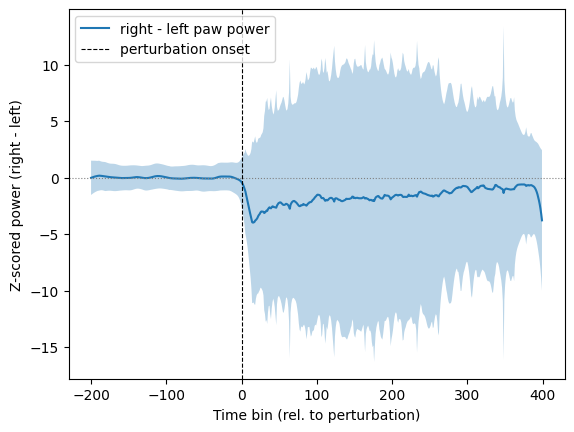

In [27]:

# Z-score each paw trace to baseline (bins 0:200 = pre-perturbation), then subtract
all_power = np.stack(td_drop.power.values)  # (n_trials, T, n_keypoints)

baseline_mean = all_power[:, :200, :].mean(axis=1, keepdims=True)  # (n_trials, 1, n_keypoints)
baseline_std  = all_power[:, :200, :].std(axis=1, keepdims=True)

all_power_norm = (all_power - baseline_mean) / (baseline_std + 1e-8)
# all_power_norm = all_power

diff_traces = all_power_norm[:, :, 7] - all_power_norm[:, :, 1]  # right - left paw

mean_diff = diff_traces.mean(axis=0)
std_diff  = diff_traces.std(axis=0)

t = np.arange(diff_traces.shape[1]) - 200  # bins relative to perturbation onset

fig, ax = plt.subplots()
ax.plot(t, mean_diff, label='right - left paw power')
ax.fill_between(t, mean_diff - std_diff, mean_diff + std_diff, alpha=0.3)
ax.axvline(0, color='k', linestyle='--', linewidth=0.8, label='perturbation onset')
ax.axhline(0, color='gray', linestyle=':', linewidth=0.8)
ax.set_xlabel('Time bin (rel. to perturbation)')
ax.set_ylabel('Z-scored power (right - left)')
ax.legend()

print(f"n_trials: {diff_traces.shape[0]}, T: {diff_traces.shape[1]}")
print(f"Mean diff range: [{mean_diff.min():.3f}, {mean_diff.max():.3f}]")
print(f"Peak at bin {t[np.argmax(np.abs(mean_diff))]}: {mean_diff[np.argmax(np.abs(mean_diff))]:.3f}")


[right paw - left paw] Dir 8 (330°, contra): n=16, peak=0.494 at bin 34
[right paw - left paw] Dir 9 (30°, ipsi): n=19, peak=-0.480 at bin 21


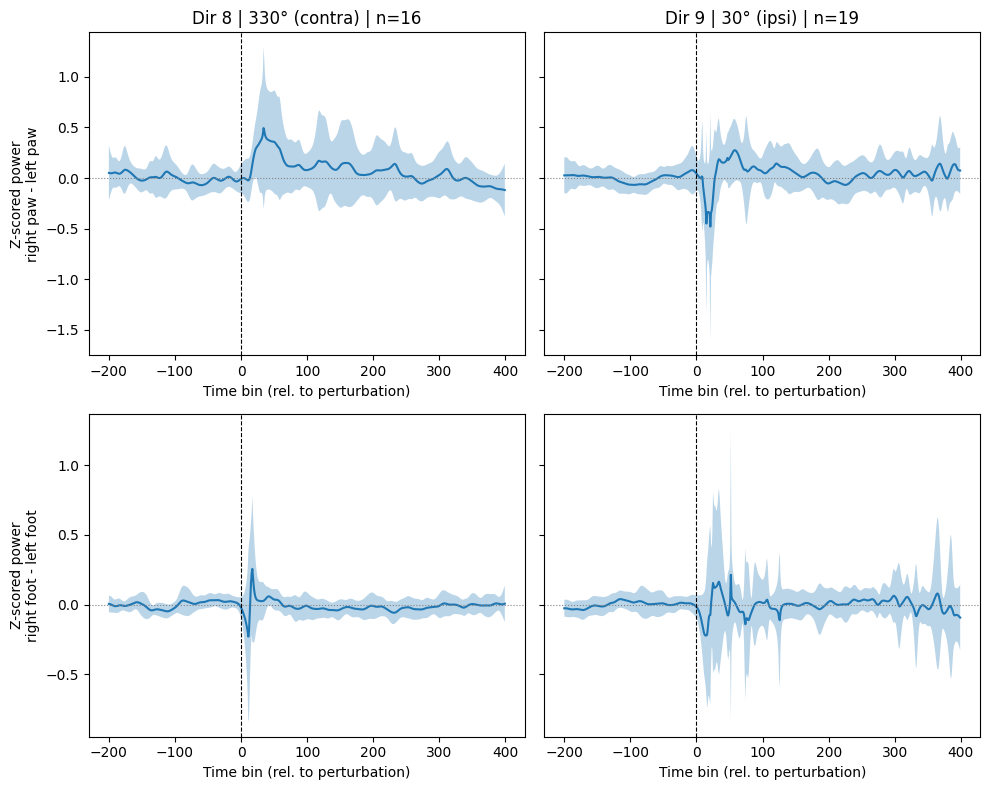

In [79]:

# --- Pick solenoid directions to compare ---
selected_dirs = [8, 9]  # any subset of 0–11
# -------------------------------------------

all_power = np.stack(td_drop.power.values)  # (n_trials, T, n_keypoints)

baseline_mean = all_power[:, :200, :].mean(axis=1, keepdims=True)
baseline_std  = all_power[:, :200, :].std(axis=1, keepdims=True)
all_power_norm = (all_power - baseline_mean) #/ (baseline_std + 1e-8)

# Row 1: right paw - left paw (indices 10, 4)
# Row 2: right foot - right paw (indices 8, 10)
row_configs = [
    (10, 4,  'right paw - left paw'),
    (8,  2, 'right foot - left foot'),
]

sol_dirs = td_drop['values_Sol_direction'].values
t = np.arange(all_power_norm.shape[1]) - 200

fig, axes = plt.subplots(2, len(selected_dirs), figsize=(5 * len(selected_dirs), 8), sharey='row')

for row, (idx_a, idx_b, row_label) in enumerate(row_configs):
    diff_traces = all_power_norm[:, :, idx_a] - all_power_norm[:, :, idx_b]
    # diff_traces = all_power_norm[:, :, idx_b]
    for col, d in enumerate(selected_dirs):
        ax = axes[row, col]
        mask = sol_dirs == d
        traces = diff_traces[mask]
        mean = traces.mean(axis=0)
        std  = traces.std(axis=0)
        angle = Params.sol_dir_to_angle[d]
        side  = 'contra' if Params.sol_dir_to_contra_ipse[d] == 1 else 'ipsi'
        ax.plot(t, mean)
        ax.fill_between(t, mean - std, mean + std, alpha=0.3)
        ax.axvline(0, color='k', linestyle='--', linewidth=0.8)
        ax.axhline(0, color='gray', linestyle=':', linewidth=0.8)
        ax.set_xlabel('Time bin (rel. to perturbation)')
        if col == 0:
            ax.set_ylabel(f'Z-scored power\n{row_label}')
        if row == 0:
            ax.set_title(f'Dir {d} | {angle}° ({side}) | n={mask.sum()}')
        if row == 0:
            print(f"[{row_label}] Dir {d} ({angle}°, {side}): n={mask.sum()}, peak={mean[np.argmax(np.abs(mean))]:.3f} at bin {t[np.argmax(np.abs(mean))]}")

plt.tight_layout()


In [94]:
td_drop = dsp.drop_trials_sem_crosses_zero(td, std=False, thresh_val=-2)

  drop_trials_sem_crosses_zero: by SEM: 322  |  by value: 444  |  kept: 312/454 (68.7%)


In [84]:
bin_edges

array([-0.86978007, -0.25697292, -0.19655238, -0.13213379, -0.03604073])

In [106]:
Params.oscillating_key_points

['left_ankle',
 'left_elbow',
 'left_foot',
 'left_knee',
 'left_paw',
 'left_wrist',
 'right_ankle',
 'right_elbow',
 'right_foot',
 'right_knee',
 'right_paw',
 'right_wrist']

In [153]:
td_drop = dsp.drop_trials_sem_crosses_zero(td, std=True, thresh_val=-2)

  drop_trials_sem_crosses_zero: by SEM: 257  |  by value: 444  |  kept: 247/454 (54.4%)


Dirs 2+8 | bin 0 [-1.40, -0.34]: n=10, peak=0.611 at bin 51
Dirs 2+8 | bin 1 [-0.34, -0.20]: n=12, peak=0.497 at bin 28
Dirs 2+8 | bin 2 [-0.20, -0.15]: n=13, peak=0.316 at bin 22
Dirs 2+8 | bin 3 [-0.15, -0.04]: n=11, peak=0.293 at bin 18
Dirs 9+3 | bin 0 [-1.40, -0.34]: n=12, peak=-0.551 at bin 21
Dirs 9+3 | bin 1 [-0.34, -0.20]: n=9, peak=-0.342 at bin 16
Dirs 9+3 | bin 2 [-0.20, -0.15]: n=8, peak=-0.860 at bin 15
Dirs 9+3 | bin 3 [-0.15, -0.04]: n=11, peak=-0.272 at bin 17


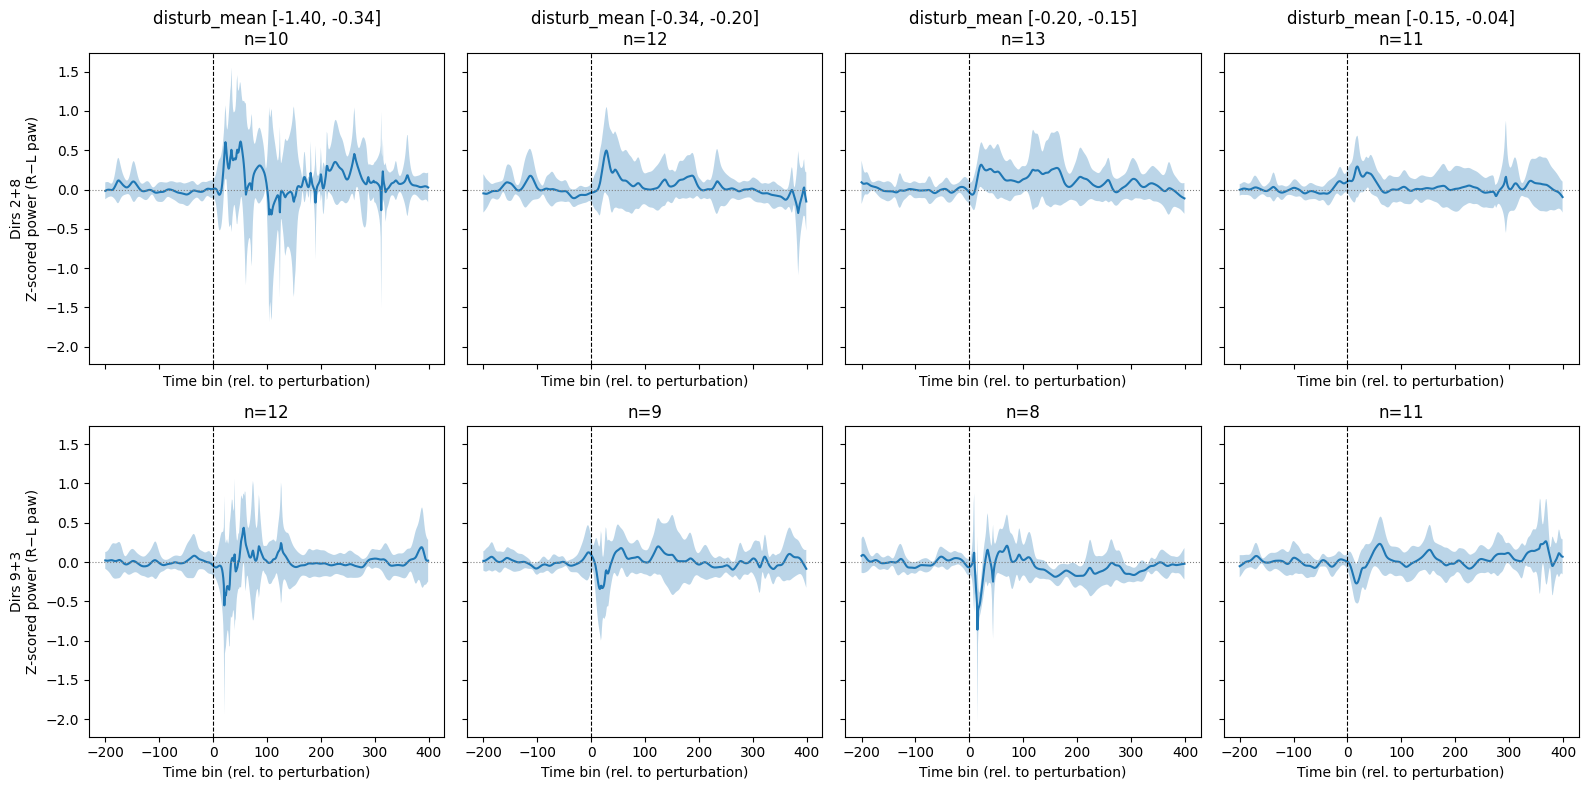

In [154]:

# ── Parameters ────────────────────────────────────────────────────────────────
dir_groups = [[2, 8], [9, 3]]   # each list is pooled into one row
n_bins     = 4                  # number of disturb_mean quantile bins
# ─────────────────────────────────────────────────────────────────────────────

all_power = np.stack(td_drop.power.values)  # (n_trials, T, n_keypoints)
baseline_mean = all_power[:, :200, :].mean(axis=1, keepdims=True)
baseline_std  = all_power[:, :200, :].std(axis=1, keepdims=True)
all_power_norm = (all_power - baseline_mean) # (baseline_std + 1e-8)

diff_traces = all_power_norm[:, :, 10] - all_power_norm[:, :, 4]  # right paw - left paw

sol_dirs = td_drop['values_Sol_direction'].values
disturb  = td_drop['disturb_mean'].values
t = np.arange(diff_traces.shape[1]) - 200

# Bin edges from all pooled trials across all groups
all_pooled = np.isin(sol_dirs, [d for grp in dir_groups for d in grp])
bin_edges  = np.quantile(disturb[all_pooled], np.linspace(0, 1, n_bins + 1))
bin_edges[0] -= 1e-6
bin_labels = [f'[{bin_edges[i]:.2f}, {bin_edges[i+1]:.2f}]' for i in range(n_bins)]

fig, axes = plt.subplots(len(dir_groups), n_bins,
                         figsize=(4 * n_bins, 4 * len(dir_groups)),
                         sharey=True, sharex=True)
if len(dir_groups) == 1:
    axes = axes[np.newaxis, :]

for row, grp in enumerate(dir_groups):
    grp_mask  = np.isin(sol_dirs, grp)
    grp_label = '+'.join(str(d) for d in grp)

    for col in range(n_bins):
        ax = axes[row, col]
        mask = grp_mask & (disturb > bin_edges[col]) & (disturb <= bin_edges[col + 1])
        traces = diff_traces[mask]

        if mask.sum() == 0:
            ax.set_title('no trials')
            continue

        mean = traces.mean(axis=0)
        std  = traces.std(axis=0)

        ax.plot(t, mean)
        ax.fill_between(t, mean - std, mean + std, alpha=0.3)
        ax.axvline(0, color='k', linestyle='--', linewidth=0.8)
        ax.axhline(0, color='gray', linestyle=':', linewidth=0.8)
        ax.set_xlabel('Time bin (rel. to perturbation)')

        if col == 0:
            ax.set_ylabel(f'Dirs {grp_label}\nZ-scored power (R−L paw)')
        if row == 0:
            ax.set_title(f'disturb_mean {bin_labels[col]}\nn={mask.sum()}')
        else:
            ax.set_title(f'n={mask.sum()}')

        print(f"Dirs {grp_label} | bin {col} {bin_labels[col]}: n={mask.sum()}, "
              f"peak={mean[np.argmax(np.abs(mean))]:.3f} at bin {t[np.argmax(np.abs(mean))]}")

plt.tight_layout()


Dirs 2+8 | bin 0 [-1.40, -0.34]: n=10 trials, peak=0.270 at bin 44
Dirs 2+8 | bin 1 [-0.34, -0.20]: n=12 trials, peak=0.265 at bin 30
Dirs 2+8 | bin 2 [-0.20, -0.15]: n=13 trials, peak=0.269 at bin 15
Dirs 2+8 | bin 3 [-0.15, -0.04]: n=11 trials, peak=0.188 at bin 18
Dirs 3+9 | bin 0 [-1.40, -0.34]: n=12 trials, peak=-0.463 at bin 21
Dirs 3+9 | bin 1 [-0.34, -0.20]: n=9 trials, peak=-0.173 at bin 15
Dirs 3+9 | bin 2 [-0.20, -0.15]: n=8 trials, peak=-0.610 at bin 15
Dirs 3+9 | bin 3 [-0.15, -0.04]: n=11 trials, peak=-0.228 at bin 14


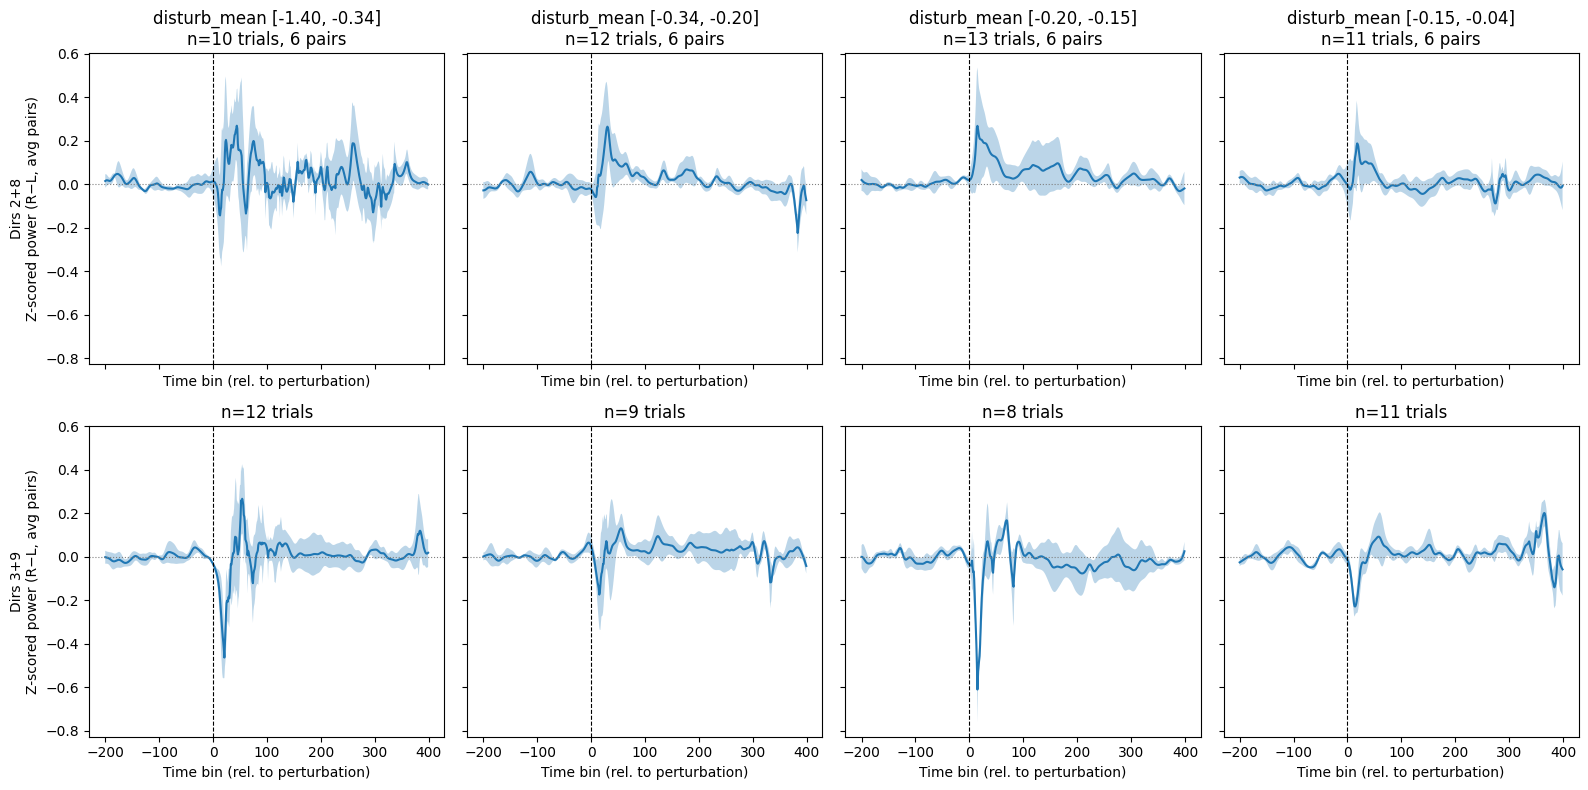

In [159]:
# ── Parameters ────────────────────────────────────────────────────────────────
dir_groups  = [[2, 8], [3, 9]]   # each list is pooled into one row
n_bins      = 4                  # number of disturb_mean quantile bins
kp_pairs    = [                  # (right_idx, left_idx) symmetric pairs
    (6,  0),   # ankle
    (7,  1),   # elbow
    (8,  2),   # foot
    (9,  3),   # knee
    (10, 4),   # paw
    (11, 5),   # wrist
]
# ─────────────────────────────────────────────────────────────────────────────

all_power = np.stack(td_drop.power.values)  # (n_trials, T, n_keypoints)
baseline_mean = all_power[:, :180, :].mean(axis=1, keepdims=True)
baseline_std  = all_power[:, :180, :].std(axis=1, keepdims=True)
all_power_norm = (all_power - baseline_mean) #/ (baseline_std + 1e-8)

# Compute right-left diff for each pair → (n_pairs, n_trials, T)
pair_diffs = np.stack([
    all_power_norm[:, :, r] - all_power_norm[:, :, l]
    for r, l in kp_pairs
])

sol_dirs = td_drop['values_Sol_direction'].values
disturb  = td_drop['disturb_mean'].values
t = np.arange(all_power_norm.shape[1]) - 200

all_pooled = np.isin(sol_dirs, [d for grp in dir_groups for d in grp])
bin_edges  = np.quantile(disturb[all_pooled], np.linspace(0, 1, n_bins + 1))
bin_edges[0] -= 1e-6
bin_labels = [f'[{bin_edges[i]:.2f}, {bin_edges[i+1]:.2f}]' for i in range(n_bins)]

fig, axes = plt.subplots(len(dir_groups), n_bins,
                         figsize=(4 * n_bins, 4 * len(dir_groups)),
                         sharey=True, sharex=True)
if len(dir_groups) == 1:
    axes = axes[np.newaxis, :]

for row, grp in enumerate(dir_groups):
    grp_mask  = np.isin(sol_dirs, grp)
    grp_label = '+'.join(str(d) for d in grp)

    for col in range(n_bins):
        ax = axes[row, col]
        mask = grp_mask & (disturb > bin_edges[col]) & (disturb <= bin_edges[col + 1])

        if mask.sum() == 0:
            ax.set_title('no trials')
            continue

        # Average over trials first, then get mean/std across pairs
        per_pair_means = pair_diffs[:, mask, :].mean(axis=1)  # (n_pairs, T)
        mean = per_pair_means.mean(axis=0)                    # (T,)
        std  = per_pair_means.std(axis=0)                     # variability across pairs

        ax.plot(t, mean)
        ax.fill_between(t, mean - std, mean + std, alpha=0.3)
        ax.axvline(0, color='k', linestyle='--', linewidth=0.8)
        ax.axhline(0, color='gray', linestyle=':', linewidth=0.8)
        ax.set_xlabel('Time bin (rel. to perturbation)')

        if col == 0:
            ax.set_ylabel(f'Dirs {grp_label}\nZ-scored power (R−L, avg pairs)')
        if row == 0:
            ax.set_title(f'disturb_mean {bin_labels[col]}\nn={mask.sum()} trials, {len(kp_pairs)} pairs')
        else:
            ax.set_title(f'n={mask.sum()} trials')

        print(f"Dirs {grp_label} | bin {col} {bin_labels[col]}: n={mask.sum()} trials, "
              f"peak={mean[np.argmax(np.abs(mean))]:.3f} at bin {t[np.argmax(np.abs(mean))]}")

plt.tight_layout()


In [162]:
all_power_norm.shape

(247, 600, 12)

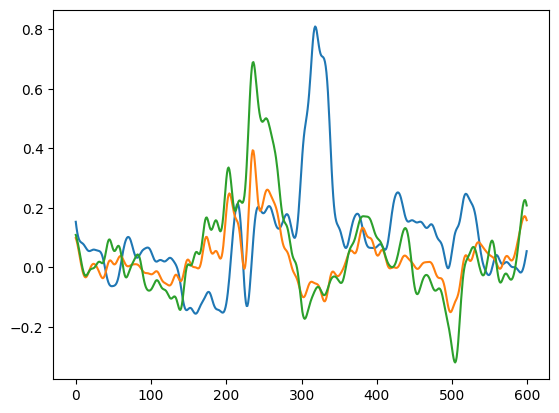

In [168]:
kp_pairs    = [                  # (right_idx, left_idx) symmetric pairs
    (6,  0),   # ankle
    (7,  1),   # elbow
    (8,  2),   # foot
    (9,  3),   # knee
    (10, 4),   # paw
    (11, 5),   # wrist
]
tr = 1
plt.plot(all_power_norm[tr, :, 10] - all_power_norm[tr, :, 4])
plt.plot(all_power_norm[tr, :, 6] - all_power_norm[tr, :, 0])
plt.plot(all_power_norm[tr, :, 9] - all_power_norm[tr, :, 3])

In [200]:
td_drop = dsp.drop_trials_sem_crosses_zero(td, std=False, thresh_val=-2)

  drop_trials_sem_crosses_zero: by SEM: 322  |  by value: 444  |  kept: 312/454 (68.7%)


In [190]:
Params.oscillating_key_points

['left_ankle',
 'left_elbow',
 'left_foot',
 'left_knee',
 'left_paw',
 'left_wrist',
 'right_ankle',
 'right_elbow',
 'right_foot',
 'right_knee',
 'right_paw',
 'right_wrist']

n_trials: 312
Pearson r=0.408, p=6.138e-14
asymmetry_score range: [0.19, 284.75]
disturb_mean range: [-0.76, 1.38]


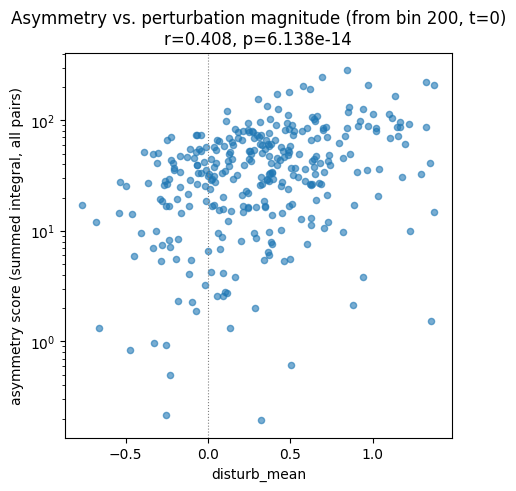

In [209]:
# ── Parameters ──────────────────────────────────────────────────────────────────────────────
kp_pairs  = [(6,0), (7,1), (8,2), (9,3), (10,4), (11,5)]  # right-left pairs
# kp_pairs  = [(7,1), (10,4), (11,5)]  # right-left pairs
# kp_pairs  = [(6,0), (8,2), (10,4)]  # right-left pairs

int_start = 200   # array index to start integration (t = int_start - 200 rel. onset)
# ───────────────────────────────────────────────────────────────────────────────

all_power = np.stack(td_drop.power.values)  # (n_trials, T, n_keypoints)

# Baseline subtract only (no std division)
baseline_mean = all_power[:, :200, :].mean(axis=1, keepdims=True)
all_power_norm = all_power - baseline_mean

# (n_pairs, n_trials, T) - right minus left per pair
pair_diffs = np.stack([
    all_power_norm[:, :, r] - all_power_norm[:, :, l]
    for r, l in kp_pairs
])

# Integrate each pair's curve from int_start onward, sum across pairs
integrated = pair_diffs[:, :, int_start:300].sum(axis=2)  # (n_pairs, n_trials)
asymmetry_score = np.abs(integrated.sum(axis=0))               # (n_trials,)

# disturb_sum = np.np.array([np.sum(x) for x in td_drop['disturb_score'].values])
disturb_mean = td_drop['disturb_sum'].values

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(disturb_mean, asymmetry_score, alpha=0.6, s=20)
ax.axhline(0, color='gray', linestyle=':', linewidth=0.8)
ax.axvline(0, color='gray', linestyle=':', linewidth=0.8)
ax.set_xlabel('disturb_mean')
ax.set_ylabel('asymmetry score (summed integral, all pairs)')
ax.set_yscale("log", base=10)
r, p = scipy.stats.pearsonr(disturb_mean, asymmetry_score)
ax.set_title(f'Asymmetry vs. perturbation magnitude (from bin {int_start}, t={int_start-200})\nr={r:.3f}, p={p:.3e}')

print(f'n_trials: {len(asymmetry_score)}')
print(f'Pearson r={r:.3f}, p={p:.3e}')
print(f'asymmetry_score range: [{asymmetry_score.min():.2f}, {asymmetry_score.max():.2f}]')
print(f'disturb_mean range: [{disturb_mean.min():.2f}, {disturb_mean.max():.2f}]')


mean:   47.14
median: 36.26
std:    43.11
range:  [0.19, 284.75]


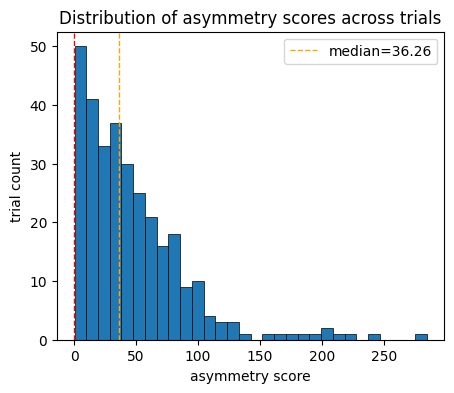

In [210]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.hist(asymmetry_score, bins=30, edgecolor='k', linewidth=0.5)
ax.axvline(0, color='r', linestyle='--', linewidth=1)
ax.axvline(np.median(asymmetry_score), color='orange', linestyle='--', linewidth=1, label=f'median={np.median(asymmetry_score):.2f}')
ax.set_xlabel('asymmetry score')
ax.set_ylabel('trial count')
ax.set_title('Distribution of asymmetry scores across trials')
ax.legend()

print(f'mean:   {asymmetry_score.mean():.2f}')
print(f'median: {np.median(asymmetry_score):.2f}')
print(f'std:    {asymmetry_score.std():.2f}')
print(f'range:  [{asymmetry_score.min():.2f}, {asymmetry_score.max():.2f}]')


# Load both sessions

In [512]:
SESSIONS = [
    # "M061_2025_03_04_10_00",
    # "M061_2025_03_05_14_00",
    # "M061_2025_03_06_14_00",
    # "M063_2025_03_13_14_00",
    # "M063_2025_03_14_15_30",
    # "M062_2025_03_20_14_00",
    # "M062_2025_03_21_14_00",
    # "M078_2025_08_06_15_00",
    # "M086_2025_12_10_15_00",
    # "M103_2026_02_18_15_30",
    # "M103_2026_02_19_15_30",
    # "M103_2026_02_20_16_00",
    "M106_2026_02_25_15_00",
    "M106_2026_02_26_16_00",
    "M106_2026_02_27_16_00"
]
all_sess_no_drop = {}
for sess in SESSIONS:
    td, _ = dsp.load_and_process_session(sess, std=0.03)
    td = pyal.restrict_to_interval(td, start_point_name='idx_sol_on', rel_start=-200, rel_end=300)
    td['power'] = td.apply(
        lambda row: row['power'][row["concat_perturb_time"] - 200:row["concat_perturb_time"] + 300, :],
        axis=1
    )
    td = dsp.drop_trials_sem_crosses_zero(td, std=True, thresh_val=-2)
    all_sess_no_drop[sess] = td

fields: ['values_before_camera_trigger', 'idx_before_camera_trigger', 'values_Sol_duration', 'values_Sol_direction'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_duration', 'idx_Sol_duration', 'values_Sol_direction', 'idx_Sol_direction', 'idx_sol_on'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_duration', 'idx_Sol_duration', 'values_Sol_direction', 'idx_Sol_direction', 'idx_sol_on'] could not be converted to int.
['CP_spikes', 'MOp_spikes', 'all_spikes', 'VAL_spikes', 'SSp_spikes']


/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of CP_spikes on 99.9001996007984% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of CP_spikes on 99.9001996007984% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of CP_spikes on 99.9001996007984% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of CP_spikes on 99.9001996007984% of trials
  warnings.warn(


Resulting CP_spikes ephys data shape is (NxT): (206, 48000)
Resulting MOp_spikes ephys data shape is (NxT): (156, 48000)
Resulting all_spikes ephys data shape is (NxT): (11, 48000)
Resulting VAL_spikes ephys data shape is (NxT): (132, 48000)
Resulting SSp_spikes ephys data shape is (NxT): (142, 48000)
add_concat_perturb_time: dropping 1 trial(s) with missing idx_sol_on
Skipped 87 trials
Otsu immobility threshold: 2.2123
Dropped 130 of 499 rows (26.05%).
  drop_trials_sem_crosses_zero: by SEM: 186  |  by value: 319  |  kept: 180/325 (55.4%)
fields: ['values_before_camera_trigger', 'idx_before_camera_trigger', 'values_Sol_direction', 'values_Sol_duration'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_direction', 'idx_Sol_direction', 'values_Sol_duration', 'idx_Sol_duration', 'idx_sol_on'] could not be converted to int.
['CP_spikes', 'all_spikes', 'MOp_spikes', 'VAL_spikes', 'SSp_spikes']


/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of CP_spikes on 99.81343283582089% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of CP_spikes on 99.81343283582089% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of CP_spikes on 99.81343283582089% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of CP_spikes on 99.81343283582089% of trials
  warnings.warn(


Resulting CP_spikes ephys data shape is (NxT): (132, 120000)
Resulting all_spikes ephys data shape is (NxT): (17, 120000)
Resulting MOp_spikes ephys data shape is (NxT): (122, 120000)
Resulting VAL_spikes ephys data shape is (NxT): (187, 120000)
Resulting SSp_spikes ephys data shape is (NxT): (77, 120000)
Skipped 10 trials
Otsu immobility threshold: 2.6951
Dropped 28 of 267 rows (10.49%).


/home/me24/repos/earthquake-analysis/notebooks/testing_stuff/../../tools/dsp/preprocessing.py:193: RuntimeWarning: divide by zero encountered in log10
  lambda a: np.log10(np.abs(np.sum(a)))
/tmp/ipykernel_1611561/2721369608.py:21: UserWarning: Dropping 1 trials because of invalid time indexing. For more information, try warn_per_trial=True
  td = pyal.restrict_to_interval(td, start_point_name='idx_sol_on', rel_start=-200, rel_end=300)


  drop_trials_sem_crosses_zero: by SEM: 117  |  by value: 233  |  kept: 116/234 (49.6%)
fields: ['values_before_camera_trigger', 'idx_before_camera_trigger', 'values_Sol_direction', 'values_Sol_duration'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_direction', 'idx_Sol_direction', 'values_Sol_duration', 'idx_Sol_duration', 'idx_sol_on'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_direction', 'values_Sol_duration'] could not be converted to int.
['CP_spikes', 'MOp_spikes', 'all_spikes', 'SSp_spikes', 'VAL_spikes']


/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of CP_spikes on 99.89939637826963% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of CP_spikes on 99.89939637826963% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of CP_spikes on 99.89939637826963% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of CP_spikes on 99.89939637826963% of trials
  warnings.warn(


Resulting CP_spikes ephys data shape is (NxT): (118, 48000)
Resulting MOp_spikes ephys data shape is (NxT): (49, 48000)
Resulting all_spikes ephys data shape is (NxT): (7, 48000)
Resulting SSp_spikes ephys data shape is (NxT): (37, 48000)
Resulting VAL_spikes ephys data shape is (NxT): (166, 48000)
add_concat_perturb_time: dropping 1 trial(s) with missing idx_sol_on
Skipped 21 trials
Otsu immobility threshold: 2.0868
Dropped 32 of 495 rows (6.46%).
  drop_trials_sem_crosses_zero: by SEM: 257  |  by value: 444  |  kept: 247/454 (54.4%)


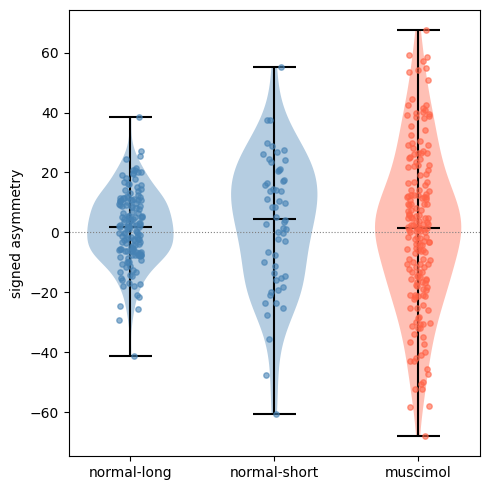

In [ ]:
# ── Parameters ──────────────────────────────────────────────────────────────────────────────
kp_pairs   = [(6,0), (7,1), (8,2), (9,3), (10,4), (11,5)]
kp_pairs   = [(10,4), (11,5)]

int_start  = 200
int_end    = 450
disturb_lo = -0.4
disturb_hi = -0.1
drop_outliers = False   # if True, drop trials outside 5th–95th percentile of pooled scores
sess_labels = {
    'M103_2026_02_18_15_30': 'normal-long',
    'M103_2026_02_19_15_30': 'normal-short',
    'M103_2026_02_20_16_00': 'muscimol',
}
# ───────────────────────────────────────────────────────────────────────────────

groups, xlabels, xcolors = [], [], []
grp_colors = {'normal-long': 'steelblue','normal-short': 'steelblue', 'muscimol': 'tomato'}


for sess, td in all_sess_no_drop.items():
    power = np.stack(td.power.values)
    baseline = power[:, :200, :].mean(axis=1, keepdims=True)
    power_norm = power - baseline
    pair_diffs = np.stack([
        power_norm[:, :, r] - power_norm[:, :, l]
        for r, l in kp_pairs
    ])
    score = pair_diffs[:, :, int_start:int_end].sum(axis=2).mean(axis=0)
    disturb = td['disturb_mean'].values
    mask = (disturb > disturb_lo) & (disturb <= disturb_hi)
    label = sess_labels.get(sess, sess)
    groups.append(score[mask])
    xlabels.append(label)
    xcolors.append(grp_colors[label])


# ── Optional: drop outlier trials (pooled across sessions) ──────────────────
if drop_outliers:
    all_scores = np.concatenate(groups)
    lo, hi = np.percentile(all_scores, [0.25, 99.75])
    groups = [g[(g >= lo) & (g <= hi)] for g in groups]

fig, ax = plt.subplots(figsize=(5, 5))
rng = np.random.default_rng(0)

parts = ax.violinplot(groups, positions=range(len(groups)), showmedians=True, showmeans=False, widths=0.6)
for pc, color in zip(parts['bodies'], xcolors):
    pc.set_facecolor(color)
    pc.set_alpha(0.4)
for partname in ('cbars', 'cmins', 'cmaxes', 'cmedians'):
    parts[partname].set_color('k')

# for i, grp in enumerate(groups):
#     ax.plot([i - 0.2, i + 0.2], [np.mean(grp), np.mean(grp)], color='k', linewidth=2, zorder=5)

for i, (grp, color) in enumerate(zip(groups, xcolors)):
    jitter = rng.uniform(-0.08, 0.08, size=len(grp))
    ax.scatter(i + jitter, grp, color=color, alpha=0.6, s=15, zorder=3)

ax.axhline(0, color='gray', linestyle=':', linewidth=0.8)
ax.set_xticks(range(len(xlabels)))
ax.set_xticklabels([f"{lbl}" for lbl, grp in zip(xlabels, groups)])
ax.set_ylabel('signed asymmetry')

if len(groups) == 2:
    stat, p = scipy.stats.mannwhitneyu(groups[0], groups[1], alternative='two-sided')
    ax.set_title(f'control vs muscimol (ipsi + contra pooled)\nMW p={p:.3e}')
    print(f'control: n={len(groups[0])}, median={np.median(groups[0]):.2f}')
    print(f'muscimol: n={len(groups[1])}, median={np.median(groups[1]):.2f}')
    print(f'Mann-Whitney p={p:.3e}')

plt.tight_layout()


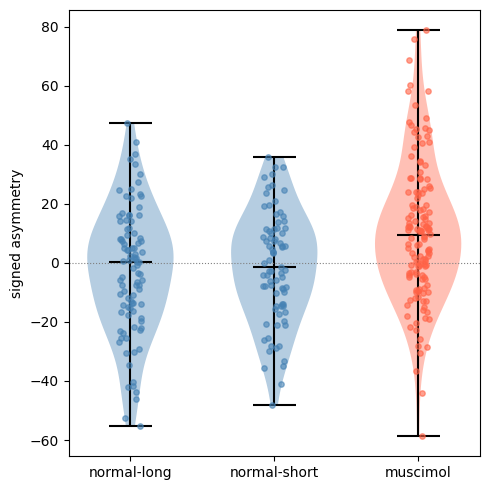

In [336]:
# ── Parameters ──────────────────────────────────────────────────────────────────────────────
# kp_pairs   = [(6,0), (7,1), (8,2), (9,3), (10,4), (11,5)]
kp_pairs   = [(10,4)]

int_start  = 200
int_end    = 350
disturb_lo = -0.36
disturb_hi = -0.1
drop_outliers = True   # if True, drop trials outside 5th–95th percentile of pooled scores
sess_labels = {
    'M106_2026_02_25_15_00': 'normal-long',
    'M106_2026_02_26_16_00': 'normal-short',
    'M106_2026_02_27_16_00': 'muscimol',
}
# ───────────────────────────────────────────────────────────────────────────────

groups, xlabels, xcolors = [], [], []
grp_colors = {'normal-long': 'steelblue','normal-short': 'steelblue', 'muscimol': 'tomato'}


for sess, td in all_sess_no_drop.items():
    power = np.stack(td.power.values)
    baseline = power[:, :200, :].mean(axis=1, keepdims=True)
    power_norm = power - baseline
    pair_diffs = np.stack([
        power_norm[:, :, r] - power_norm[:, :, l]
        for r, l in kp_pairs
    ])
    score = pair_diffs[:, :, int_start:int_end].sum(axis=2).mean(axis=0)
    disturb = td['disturb_mean'].values
    mask = (disturb > disturb_lo) & (disturb <= disturb_hi)
    label = sess_labels.get(sess, sess)
    groups.append(score[mask])
    xlabels.append(label)
    xcolors.append(grp_colors[label])


# ── Optional: drop outlier trials (pooled across sessions) ──────────────────
if drop_outliers:
    all_scores = np.concatenate(groups)
    lo, hi = np.percentile(all_scores, [0.25, 99.75])
    groups = [g[(g >= lo) & (g <= hi)] for g in groups]

fig, ax = plt.subplots(figsize=(5, 5))
rng = np.random.default_rng(0)

parts = ax.violinplot(groups, positions=range(len(groups)), showmedians=True, showmeans=False, widths=0.6)
for pc, color in zip(parts['bodies'], xcolors):
    pc.set_facecolor(color)
    pc.set_alpha(0.4)
for partname in ('cbars', 'cmins', 'cmaxes', 'cmedians'):
    parts[partname].set_color('k')

# for i, grp in enumerate(groups):
#     ax.plot([i - 0.2, i + 0.2], [np.mean(grp), np.mean(grp)], color='k', linewidth=2, zorder=5)

for i, (grp, color) in enumerate(zip(groups, xcolors)):
    jitter = rng.uniform(-0.08, 0.08, size=len(grp))
    ax.scatter(i + jitter, grp, color=color, alpha=0.6, s=15, zorder=3)

ax.axhline(0, color='gray', linestyle=':', linewidth=0.8)
ax.set_xticks(range(len(xlabels)))
ax.set_xticklabels([f"{lbl}" for lbl, grp in zip(xlabels, groups)])
ax.set_ylabel('signed asymmetry')

if len(groups) == 2:
    stat, p = scipy.stats.mannwhitneyu(groups[0], groups[1], alternative='two-sided')
    ax.set_title(f'control vs muscimol (ipsi + contra pooled)\nMW p={p:.3e}')
    print(f'control: n={len(groups[0])}, median={np.median(groups[0]):.2f}')
    print(f'muscimol: n={len(groups[1])}, median={np.median(groups[1]):.2f}')
    print(f'Mann-Whitney p={p:.3e}')

plt.tight_layout()


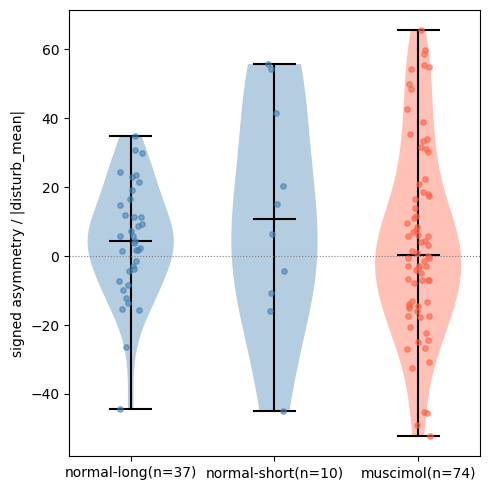

In [440]:
# ── Parameters ──────────────────────────────────────────────────────────────────────────────
kp_pairs   = [(6,0), (7,1), (8,2), (9,3)]
# kp_pairs   = [(10,4)]

int_start  = 200
int_end    = 350
disturb_lo = -0.8
disturb_hi = -0.3
drop_outliers = True
sess_labels = {
    'M103_2026_02_18_15_30': 'normal-long',
    'M103_2026_02_19_15_30': 'normal-short',
    'M103_2026_02_20_16_00': 'muscimol',
}
# ───────────────────────────────────────────────────────────────────────────────

groups, xlabels, xcolors = [], [], []
grp_colors = {'normal-long': 'steelblue','normal-short': 'steelblue', 'muscimol': 'tomato'}

for sess, td in all_sess_no_drop.items():
    power = np.stack(td.power.values)
    baseline = power[:, :200, :].mean(axis=1, keepdims=True)
    power_norm = power - baseline
    pair_diffs = np.stack([
        power_norm[:, :, r] - power_norm[:, :, l]
        for r, l in kp_pairs
    ])
    score = pair_diffs[:, :, int_start:int_end].sum(axis=2).mean(axis=0)

    # Normalise by total disturbance magnitude (more negative = larger disturbance)
    disturb = td['disturb_mean'].values
    score_norm = score / (np.abs(td['disturb_sum'].values) + 1e-8)

    mask = (disturb > disturb_lo) & (disturb <= disturb_hi)
    label = sess_labels.get(sess, sess)
    groups.append(score_norm[mask])
    xlabels.append(label)
    xcolors.append(grp_colors[label])

if drop_outliers:
    all_scores = np.concatenate(groups)
    lo, hi = np.percentile(all_scores, [0.25, 99.75])
    groups = [g[(g >= lo) & (g <= hi)] for g in groups]

fig, ax = plt.subplots(figsize=(5, 5))
rng = np.random.default_rng(0)

parts = ax.violinplot(groups, positions=range(len(groups)), showmedians=True, showmeans=False, widths=0.6)
for pc, color in zip(parts['bodies'], xcolors):
    pc.set_facecolor(color)
    pc.set_alpha(0.4)
for partname in ('cbars', 'cmins', 'cmaxes', 'cmedians'):
    parts[partname].set_color('k')

for i, (grp, color) in enumerate(zip(groups, xcolors)):
    jitter = rng.uniform(-0.08, 0.08, size=len(grp))
    ax.scatter(i + jitter, grp, color=color, alpha=0.6, s=15, zorder=3)

ax.axhline(0, color='gray', linestyle=':', linewidth=0.8)
ax.set_xticks(range(len(xlabels)))
ax.set_xticklabels([f"{lbl}(n={len(grp)})" for lbl, grp in zip(xlabels, groups)])
ax.set_ylabel('signed asymmetry / |disturb_mean|')

if len(groups) == 2:
    stat, p = scipy.stats.mannwhitneyu(groups[0], groups[1], alternative='two-sided')
    ax.set_title(f'asymmetry normalised by disturbanceMW p={p:.3e}')
    print(f'control: n={len(groups[0])}, median={np.median(groups[0]):.3f}')
    print(f'muscimol: n={len(groups[1])}, median={np.median(groups[1]):.3f}')
    print(f'Mann-Whitney p={p:.3e}')

plt.tight_layout()


normal-long: n=226, median=2.33, mean=2.09
normal-short: n=68, median=5.02, mean=2.07
muscimol: n=223, median=-1.11, mean=-0.07


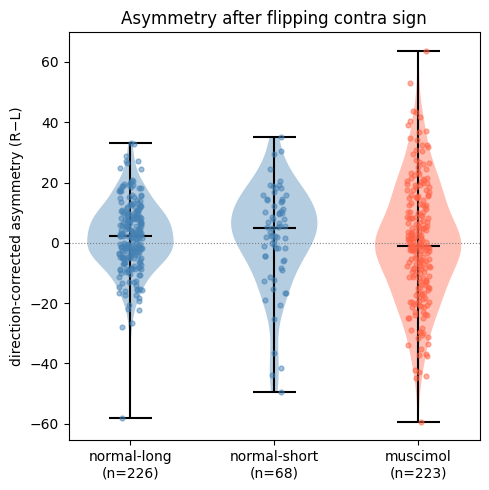

In [370]:
# ── Idea 1: direction-corrected asymmetry (flip sign for contra trials) ──────
# Contra perturbations push animal one way, ipsi the other → their asymmetries
# cancel when pooled. Flip contra sign so both point in the "expected" direction.

kp_pairs  = [(10, 4)]   # right paw - left paw
int_start = 200
int_end   = 300
sess_labels = {
    'M103_2026_02_18_15_30': 'normal-long',
    'M103_2026_02_19_15_30': 'normal-short',
    'M103_2026_02_20_16_00': 'muscimol',
}
grp_colors = {'normal-long': 'steelblue', 'normal-short': 'steelblue', 'muscimol': 'tomato'}

groups, xlabels, xcolors = [], [], []

for sess, td in all_sess_no_drop.items():
    power     = np.stack(td.power.values)
    baseline  = power[:, :200, :].mean(axis=1, keepdims=True)
    power_norm = power - baseline
    pair_diffs = np.stack([
        power_norm[:, :, r] - power_norm[:, :, l]
        for r, l in kp_pairs
    ])
    score = pair_diffs[:, :, int_start:int_end].sum(axis=2).mean(axis=0)

    # flip sign for contra trials so all trials point same direction
    contra = td['sol_contra_ipsi'].values   # 1 = contra
    score_corrected = score * np.where(contra == 1, -1, 1)

    label = sess_labels.get(sess, sess)
    groups.append(score_corrected)
    xlabels.append(label)
    xcolors.append(grp_colors[label])

fig, ax = plt.subplots(figsize=(5, 5))
rng = np.random.default_rng(0)

parts = ax.violinplot(groups, positions=range(len(groups)), showmedians=True, widths=0.6)
for pc, color in zip(parts['bodies'], xcolors):
    pc.set_facecolor(color); pc.set_alpha(0.4)
for partname in ('cbars', 'cmins', 'cmaxes', 'cmedians'):
    parts[partname].set_color('k')
for i, (grp, color) in enumerate(zip(groups, xcolors)):
    jitter = rng.uniform(-0.08, 0.08, size=len(grp))
    ax.scatter(i + jitter, grp, color=color, alpha=0.5, s=12, zorder=3)

ax.axhline(0, color='gray', linestyle=':', linewidth=0.8)
ax.set_xticks(range(len(xlabels)))
ax.set_xticklabels([f"{lbl}\n(n={len(grp)})" for lbl, grp in zip(xlabels, groups)])
ax.set_ylabel('direction-corrected asymmetry (R−L)')
ax.set_title('Asymmetry after flipping contra sign')

for i, grp in enumerate(groups):
    print(f"{xlabels[i]}: n={len(grp)}, median={np.median(grp):.2f}, mean={np.mean(grp):.2f}")

if len(groups) == 2:
    stat, p = scipy.stats.mannwhitneyu(groups[0], groups[1], alternative='two-sided')
    print(f"Mann-Whitney p={p:.3e}")

plt.tight_layout()


In [378]:
score[0]

6.237605977420133

In [389]:
pair_diffs[:, :, int_start:end].sum(axis=2).shape

(1, 223)

In [412]:
sess

('M103_2026_02_18_15_30', 'normal-long')

normal-long: n=143 trials in disturb range [-0.36, -0.1]
muscimol: n=166 trials in disturb range [-0.36, -0.1]
Best window: [232–272] bins (0.72–1.12s), p=1.780e-10


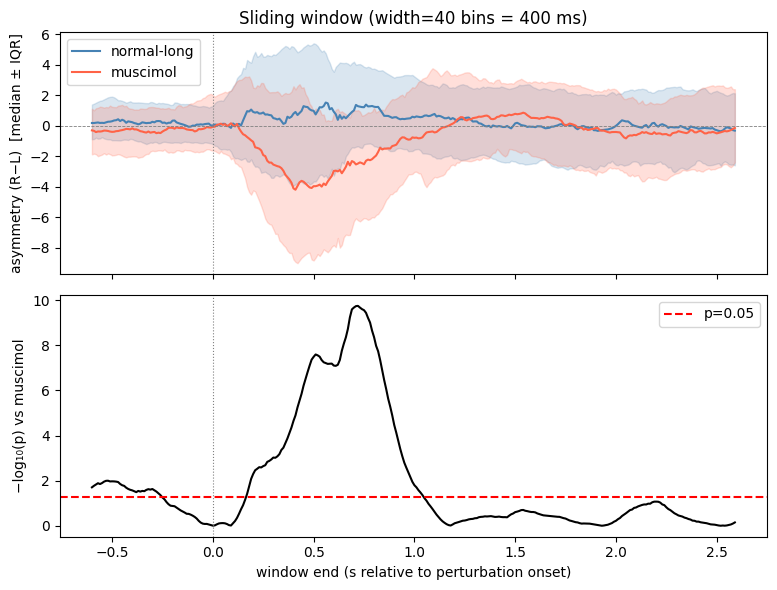

In [422]:
# ── Idea 2: sliding window sweep to find when sessions diverge most ───────────
# Toggle sessions by commenting them out in sess_labels.

kp_pairs    = [(9,3), (6,0)]
window_size = 40       # width of integration window in bins (1 bin = 10 ms)
starts      = np.arange(100, 420, 1)
disturb_lo  = -0.36
disturb_hi  = -0.1
sess_labels = {
    'M103_2026_02_18_15_30': 'normal-long',
    # 'M103_2026_02_19_15_30': 'normal-short',
    'M103_2026_02_20_16_00': 'muscimol',
}
grp_colors = {'normal-long': 'steelblue', 'normal-short': 'k', 'muscimol': 'tomato'}

active_sessions = list(sess_labels.keys())

# pre-compute normalised power and masks once
sess_data = {}
for sess in active_sessions:
    td         = all_sess_no_drop[sess]
    power      = np.stack(td.power.values)
    baseline   = power[:, :200, :].mean(axis=1, keepdims=True)
    power_norm = power - baseline
    pair_diffs = np.stack([
        power_norm[:, :, r] - power_norm[:, :, l]
        for r, l in kp_pairs
    ])                              # (n_pairs, n_trials, T)
    disturb = td['disturb_mean'].values
    mask    = (disturb > disturb_lo) & (disturb <= disturb_hi)
    sess_data[sess] = {'diffs': pair_diffs, 'mask': mask}
    print(f"{sess_labels[sess]}: n={mask.sum()} trials in disturb range [{disturb_lo}, {disturb_hi}]")

medians_per_sess = {sess: [] for sess in active_sessions}
lo_per_sess      = {sess: [] for sess in active_sessions}   # 25th pct
hi_per_sess      = {sess: [] for sess in active_sessions}   # 75th pct
pvals = []

for start in starts:
    end  = start + window_size
    grps = []
    for sess in active_sessions:
        d     = sess_data[sess]
        score = d['diffs'][:, :, start:end].sum(axis=2).mean(axis=0)[d['mask']]
        grps.append(score)
        medians_per_sess[sess].append(np.median(score))
        lo_per_sess[sess].append(np.percentile(score, 25))
        hi_per_sess[sess].append(np.percentile(score, 75))
    if len(grps) == 2:
        _, p = scipy.stats.mannwhitneyu(grps[0], grps[-1], alternative='two-sided')
        pvals.append(p)

fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
t_axis = (starts - 200 + window_size) * 0.01

for sess in active_sessions:
    label  = sess_labels[sess]
    color  = grp_colors[label]
    med    = np.array(medians_per_sess[sess])
    lo     = np.array(lo_per_sess[sess])
    hi     = np.array(hi_per_sess[sess])
    axes[0].plot(t_axis, med, label=label, color=color, linewidth=1.5)
    axes[0].fill_between(t_axis, lo, hi, color=color, alpha=0.2)

axes[0].axvline(0, color='gray', linestyle=':', linewidth=0.8)
axes[0].axhline(0, color='gray', linestyle='--', linewidth=0.6)
axes[0].set_ylabel('asymmetry (R−L)  [median ± IQR]')
axes[0].legend()
axes[0].set_title(f'Sliding window (width={window_size} bins = {window_size*10} ms)')

if pvals:
    axes[1].plot(t_axis, -np.log10(np.array(pvals)), color='k')
    axes[1].axhline(-np.log10(0.05), color='r', linestyle='--', label='p=0.05')
    best_idx = np.argmin(pvals)
    print(f"Best window: [{starts[best_idx]}–{starts[best_idx]+window_size}] bins "
          f"({t_axis[best_idx]:.2f}–{t_axis[best_idx]+window_size*0.01:.2f}s), p={pvals[best_idx]:.3e}")
else:
    axes[1].text(0.5, 0.5, 'need 2 sessions for MW test', ha='center', transform=axes[1].transAxes)

axes[1].axvline(0, color='gray', linestyle=':', linewidth=0.8)
axes[1].set_ylabel('−log₁₀(p) vs muscimol')
axes[1].set_xlabel('window end (s relative to perturbation onset)')
axes[1].legend()

plt.tight_layout()


ankle: p=7.921e-03, medians=['-0.59', '8.20', '-5.46']
elbow: p=4.055e-01, medians=['-1.95', '5.49', '0.48']
foot: p=4.526e-01, medians=['2.46', '8.64', '4.22']
knee: p=8.596e-09, medians=['5.23', '-0.30', '-3.93']
paw: p=9.788e-01, medians=['0.19', '-2.64', '-0.73']
wrist: p=7.625e-01, medians=['1.12', '-1.37', '1.16']


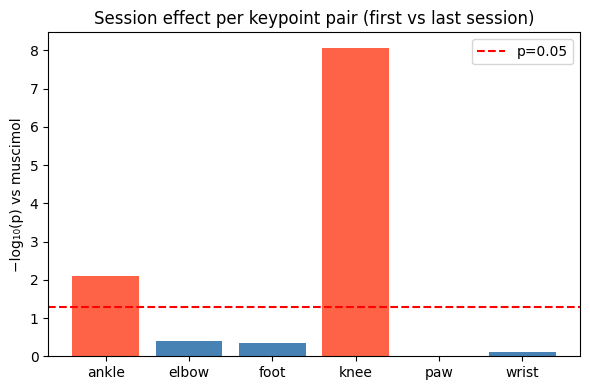

In [386]:
# ── Idea 3: compare MW p-value across all 6 keypoint pairs ───────────────────
# keypoint order: left_ankle(0), left_elbow(1), left_foot(2), left_knee(3),
#                 left_paw(4), left_wrist(5), right_ankle(6), right_elbow(7),
#                 right_foot(8), right_knee(9), right_paw(10), right_wrist(11)

all_kp_pairs  = [(6,0,'ankle'), (7,1,'elbow'), (8,2,'foot'),
                 (9,3,'knee'), (10,4,'paw'), (11,5,'wrist')]
int_start, int_end = 200, 350
sess_labels = {
    'M103_2026_02_18_15_30': 'normal-long',
    'M103_2026_02_19_15_30': 'normal-short',
    'M103_2026_02_20_16_00': 'muscimol',
}

pair_names, pvals, medians = [], [], {s: [] for s in all_sess_no_drop}

for r_idx, l_idx, name in all_kp_pairs:
    grps = []
    for sess, td in all_sess_no_drop.items():
        power      = np.stack(td.power.values)
        baseline   = power[:, :200, :].mean(axis=1, keepdims=True)
        power_norm = power - baseline
        score      = (power_norm[:, :, r_idx] - power_norm[:, :, l_idx])[:, int_start:int_end].sum(axis=1)
        grps.append(score)
        medians[sess].append(np.median(score))
    sess_list = list(all_sess_no_drop.keys())
    _, p = scipy.stats.mannwhitneyu(grps[0], grps[-1], alternative='two-sided')
    pvals.append(p)
    pair_names.append(name)
    print(f"{name}: p={p:.3e}, medians={[f'{np.median(g):.2f}' for g in grps]}")

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(pair_names, -np.log10(pvals), color=['tomato' if p < 0.05 else 'steelblue' for p in pvals])
ax.axhline(-np.log10(0.05), color='r', linestyle='--', label='p=0.05')
ax.set_ylabel('−log₁₀(p) vs muscimol')
ax.set_title('Session effect per keypoint pair (first vs last session)')
ax.legend()
plt.tight_layout()


In [494]:
disturb

array([[ 0.0152873 , -0.10496037],
       [-0.59031797, -0.58020085],
       [-0.73012531, -0.48358149],
       [-0.14025322, -0.10688641],
       [-0.02846762, -0.10466634],
       [-0.6024341 , -0.47853772],
       [-0.58236751, -0.37270004],
       [-0.40911958, -0.32764215],
       [-0.47113192, -0.72808183],
       [-0.21007575, -0.13450793],
       [-0.20567945, -0.12647603],
       [-0.27374861, -0.09550759],
       [-0.43152544, -0.28613289],
       [-0.06233778, -0.18600274],
       [-0.29074405, -0.17857493],
       [-0.14882319, -0.16883534],
       [-0.42070354, -0.35309222],
       [-0.51116144, -0.49985221],
       [-0.18349153, -0.12725437],
       [-0.19621805, -0.11740119],
       [-0.05980115, -0.19920507],
       [-0.13062589, -0.10347477],
       [-0.30430014, -0.40157048],
       [-0.209204  , -0.26327958],
       [-0.15841931, -0.12533386],
       [-0.3438064 , -0.24598073],
       [-0.31568366, -0.15899831],
       [-0.06742887, -0.04866357],
       [-0.21109341,

In [503]:
len(groups)

3

normal-long: median=0.218, mean=0.260
muscimol: median=0.324, mean=0.352
Mann-Whitney p=2.636e-11


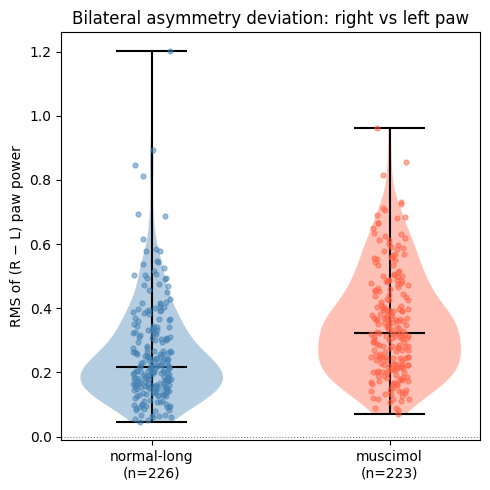

In [511]:
# ── Idea 4: bilateral coupling — correlation between right and left paw power ─
# Muscimol might reduce coordination rather than shift which side is stronger.

int_start, int_end = 200, 300
disturb_lo = -np.inf   # e.g. -0.5
disturb_hi =  np.inf   # e.g. -0.05
sess_labels = {
    'M103_2026_02_18_15_30': 'normal-long',
    # 'M103_2026_02_19_15_30': 'normal-short',
    'M103_2026_02_20_16_00': 'muscimol',
}
grp_colors = {'normal-long': 'steelblue', 'normal-short': 'steelblue', 'muscimol': 'tomato'}

active_sessions = list(sess_labels.keys())
groups, xlabels, xcolors = [], [], []

for sess in active_sessions:
    td         = all_sess_no_drop[sess]
    power      = np.stack(td.power.values)
    baseline   = power[:, 50:150, :].mean(axis=1, keepdims=True)
    power_norm = power - baseline

    right = power_norm[:, int_start:int_end, 10]   # right paw
    left  = power_norm[:, int_start:int_end, 4]    # left paw

    diff  = right - left                                        # (n_trials, T)
    score = np.sqrt((diff ** 2).mean(axis=1))                  # (n_trials,)

    disturb = np.stack(td['disturb_score'].values)[:, [4, 10]]
    disturb = disturb.mean(-1)
    mask    = (disturb > disturb_lo) & (disturb <= disturb_hi)
    label   = sess_labels[sess]
    groups.append(score[mask])
    xlabels.append(label)
    xcolors.append(grp_colors[label])

fig, ax = plt.subplots(figsize=(5, 5))
rng = np.random.default_rng(0)

parts = ax.violinplot(groups, positions=range(len(groups)), showmedians=True, widths=0.6)
for pc, color in zip(parts['bodies'], xcolors):
    pc.set_facecolor(color); pc.set_alpha(0.4)
for partname in ('cbars', 'cmins', 'cmaxes', 'cmedians'):
    parts[partname].set_color('k')
for i, (grp, color) in enumerate(zip(groups, xcolors)):
    jitter = rng.uniform(-0.08, 0.08, size=len(grp))
    ax.scatter(i + jitter, grp, color=color, alpha=0.5, s=12, zorder=3)

ax.axhline(0, color='gray', linestyle=':', linewidth=0.8)
ax.set_xticks(range(len(xlabels)))
ax.set_xticklabels([f"{lbl}\n(n={len(grp)})" for lbl, grp in zip(xlabels, groups)])
ax.set_ylabel('RMS of (R − L) paw power')
ax.set_title('Bilateral asymmetry deviation: right vs left paw')

for lbl, grp in zip(xlabels, groups):
    print(f"{lbl}: median={np.median(grp):.3f}, mean={np.mean(grp):.3f}")

if len(groups) == 2:
    stat, p = scipy.stats.mannwhitneyu(groups[0], groups[1], alternative='two-sided')
    print(f"Mann-Whitney p={p:.3e}")

plt.tight_layout()


normal-long: median=0.531, mean=0.580
normal-short: median=0.598, mean=0.624
muscimol: median=0.380, mean=0.414


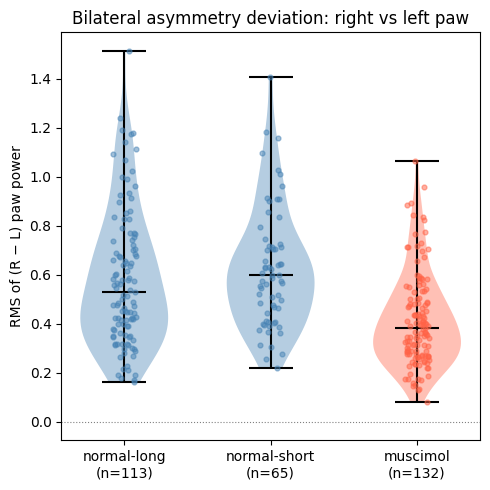

In [519]:
# ── Idea 4: bilateral coupling — correlation between right and left paw power ─
# Muscimol might reduce coordination rather than shift which side is stronger.

int_start, int_end = 200, 300
disturb_lo = -0.4   # e.g. -0.5
disturb_hi =  -0.1  # e.g. -0.05
sess_labels = {
    'M106_2026_02_25_15_00': 'normal-long',
    'M106_2026_02_26_16_00': 'normal-short',
    'M106_2026_02_27_16_00': 'muscimol',
}
grp_colors = {'normal-long': 'steelblue', 'normal-short': 'steelblue', 'muscimol': 'tomato'}

active_sessions = list(sess_labels.keys())
groups, xlabels, xcolors = [], [], []

for sess in active_sessions:
    td         = all_sess_no_drop[sess]
    power      = np.stack(td.power.values)
    baseline   = power[:, 50:150, :].mean(axis=1, keepdims=True)
    power_norm = power - baseline

    right = power_norm[:, int_start:int_end, 9]   # right paw
    left  = power_norm[:, int_start:int_end, 1]    # left paw

    diff  = right - left                                        # (n_trials, T)
    score = np.sqrt((diff ** 2).mean(axis=1))                  # (n_trials,)

    disturb = np.stack(td['disturb_score'].values)[:, [1, 9]]
    disturb = disturb.mean(-1)
    mask    = (disturb > disturb_lo) & (disturb <= disturb_hi)
    label   = sess_labels[sess]
    groups.append(score[mask])
    xlabels.append(label)
    xcolors.append(grp_colors[label])

fig, ax = plt.subplots(figsize=(5, 5))
rng = np.random.default_rng(0)

parts = ax.violinplot(groups, positions=range(len(groups)), showmedians=True, widths=0.6)
for pc, color in zip(parts['bodies'], xcolors):
    pc.set_facecolor(color); pc.set_alpha(0.4)
for partname in ('cbars', 'cmins', 'cmaxes', 'cmedians'):
    parts[partname].set_color('k')
for i, (grp, color) in enumerate(zip(groups, xcolors)):
    jitter = rng.uniform(-0.08, 0.08, size=len(grp))
    ax.scatter(i + jitter, grp, color=color, alpha=0.5, s=12, zorder=3)

ax.axhline(0, color='gray', linestyle=':', linewidth=0.8)
ax.set_xticks(range(len(xlabels)))
ax.set_xticklabels([f"{lbl}\n(n={len(grp)})" for lbl, grp in zip(xlabels, groups)])
ax.set_ylabel('RMS of (R − L) paw power')
ax.set_title('Bilateral asymmetry deviation: right vs left paw')

for lbl, grp in zip(xlabels, groups):
    print(f"{lbl}: median={np.median(grp):.3f}, mean={np.mean(grp):.3f}")

if len(groups) == 2:
    stat, p = scipy.stats.mannwhitneyu(groups[0], groups[1], alternative='two-sided')
    print(f"Mann-Whitney p={p:.3e}")

plt.tight_layout()


normal-long: n=107, median=0.366
normal-short: n=88, median=0.301
muscimol: n=149, median=0.260
MW normal-long vs muscimol: p=2.156e-07
MW normal-long vs normal-short: p=7.169e-03


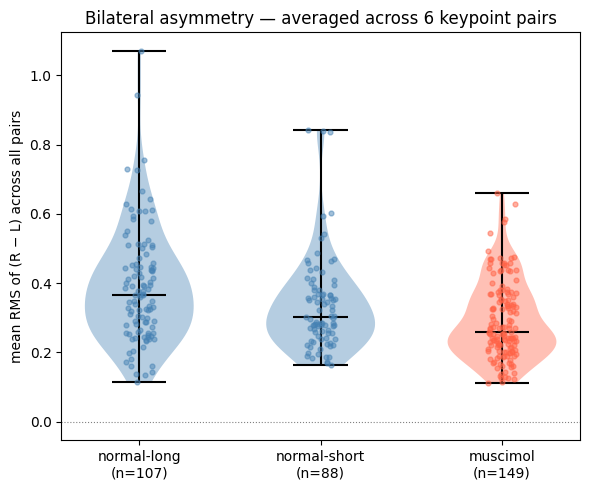

In [520]:
# ── RMS asymmetry averaged across all bilateral keypoint pairs ────────────────
# keypoint order: left_ankle(0), left_elbow(1), left_foot(2), left_knee(3),
#                 left_paw(4), left_wrist(5), right_ankle(6), right_elbow(7),
#                 right_foot(8), right_knee(9), right_paw(10), right_wrist(11)

kp_pairs = [
    (6,0,'ankle'), 
    (7,1,'elbow'), 
    (8,2,'foot'),
    (9,3,'knee'), 
    (10,4,'paw'), 
    (11,5,'wrist')
    ]

int_start, int_end = 200, 300
disturb_lo = -0.4
disturb_hi =  -0.1
sess_labels = {
    'M106_2026_02_25_15_00': 'normal-long',
    'M106_2026_02_26_16_00': 'normal-short',
    'M106_2026_02_27_16_00': 'muscimol',
}
grp_colors = {'normal-long': 'steelblue', 'normal-short': 'steelblue', 'muscimol': 'tomato'}

active_sessions = list(sess_labels.keys())
groups, xlabels, xcolors = [], [], []

for sess in active_sessions:
    td         = all_sess_no_drop[sess]
    power      = np.stack(td.power.values)
    baseline   = power[:, 50:150, :].mean(axis=1, keepdims=True)
    power_norm = power - baseline

    # RMS per pair, then average across pairs
    pair_rms = []
    for r_idx, l_idx, name in kp_pairs:
        diff = power_norm[:, int_start:int_end, r_idx] - power_norm[:, int_start:int_end, l_idx]
        pair_rms.append(np.sqrt((diff ** 2).mean(axis=1)))   # (n_trials,)
    score = np.mean(np.stack(pair_rms), axis=0)              # (n_trials,)

    disturb = td['disturb_mean'].values
    mask    = (disturb > disturb_lo) & (disturb <= disturb_hi)
    label   = sess_labels[sess]
    groups.append(score[mask])
    xlabels.append(label)
    xcolors.append(grp_colors[label])
    print(f"{label}: n={mask.sum()}, median={np.median(score[mask]):.3f}")

fig, ax = plt.subplots(figsize=(6, 5))
rng = np.random.default_rng(0)

parts = ax.violinplot(groups, positions=range(len(groups)), showmedians=True, widths=0.6)
for pc, color in zip(parts['bodies'], xcolors):
    pc.set_facecolor(color); pc.set_alpha(0.4)
for partname in ('cbars', 'cmins', 'cmaxes', 'cmedians'):
    parts[partname].set_color('k')
for i, (grp, color) in enumerate(zip(groups, xcolors)):
    jitter = rng.uniform(-0.08, 0.08, size=len(grp))
    ax.scatter(i + jitter, grp, color=color, alpha=0.5, s=12, zorder=3)

ax.axhline(0, color='gray', linestyle=':', linewidth=0.8)
ax.set_xticks(range(len(xlabels)))
ax.set_xticklabels([f"{lbl}\n(n={len(grp)})" for lbl, grp in zip(xlabels, groups)])
ax.set_ylabel('mean RMS of (R − L) across all pairs')
ax.set_title('Bilateral asymmetry — averaged across 6 keypoint pairs')

if len(groups) >= 2:
    stat, p = scipy.stats.mannwhitneyu(groups[0], groups[-1], alternative='two-sided')
    print(f"MW normal-long vs muscimol: p={p:.3e}")
if len(groups) == 3:
    stat2, p2 = scipy.stats.mannwhitneyu(groups[0], groups[1], alternative='two-sided')
    print(f"MW normal-long vs normal-short: p={p2:.3e}")

plt.tight_layout()


--- ipsi ---
  normal-long: n=83, median=0.452
  normal-short: n=59, median=0.553
  muscimol: n=142, median=0.399
  MW normal-long vs muscimol: p=2.951e-02
--- contra ---
  normal-long: n=97, median=0.603
  normal-short: n=57, median=0.473
  muscimol: n=105, median=0.320
  MW normal-long vs muscimol: p=1.390e-09


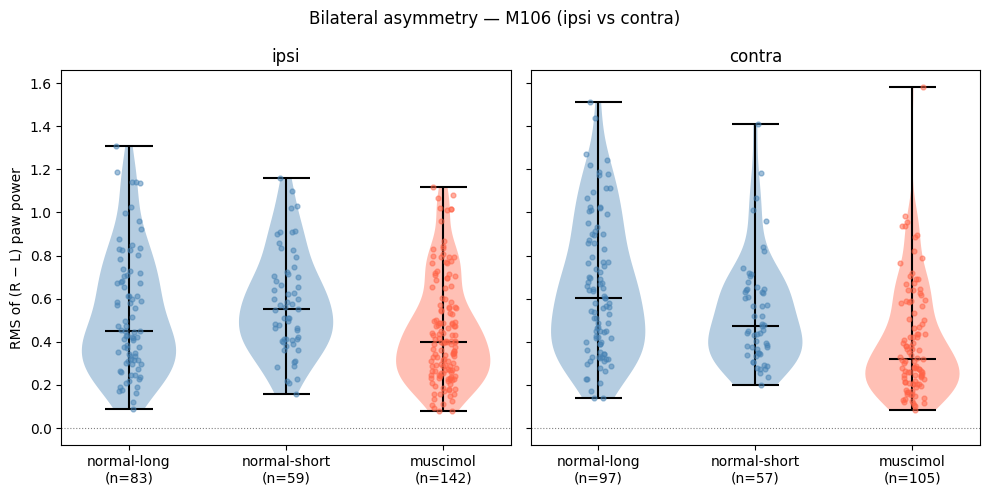

In [523]:
# ── RMS bilateral asymmetry — M106, split by ipsi / contra ───────────────────

int_start, int_end = 200, 300
disturb_lo = -np.inf
disturb_hi = np.inf
sess_labels = {
    'M106_2026_02_25_15_00': 'normal-long',
    'M106_2026_02_26_16_00': 'normal-short',
    'M106_2026_02_27_16_00': 'muscimol',
}
grp_colors = {'normal-long': 'steelblue', 'normal-short': 'steelblue', 'muscimol': 'tomato'}
active_sessions = list(sess_labels.keys())
sides = [(0, 'ipsi'), (1, 'contra')]

fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)
rng = np.random.default_rng(0)

# pre-compute scores once per session
sess_scores  = {}
sess_disturb = {}
sess_side    = {}
for sess in active_sessions:
    td         = all_sess_no_drop[sess]
    power      = np.stack(td.power.values)
    baseline   = power[:, 50:150, :].mean(axis=1, keepdims=True)
    power_norm = power - baseline
    right = power_norm[:, int_start:int_end, 9]
    left  = power_norm[:, int_start:int_end, 1]
    diff  = right - left
    sess_scores[sess]  = np.sqrt((diff ** 2).mean(axis=1))
    sess_disturb[sess] = np.stack(td['disturb_score'].values)[:, [1, 9]].mean(-1)
    sess_side[sess]    = td['sol_contra_ipsi'].values

for ax, (side_val, side_name) in zip(axes, sides):
    groups, xlabels, xcolors = [], [], []
    for sess in active_sessions:
        disturb   = sess_disturb[sess]
        side_mask = sess_side[sess] == side_val
        mask      = (disturb > disturb_lo) & (disturb <= disturb_hi) & side_mask
        label     = sess_labels[sess]
        groups.append(sess_scores[sess][mask])
        xlabels.append(label)
        xcolors.append(grp_colors[label])

    parts = ax.violinplot(groups, positions=range(len(groups)), showmedians=True, widths=0.6)
    for pc, color in zip(parts['bodies'], xcolors):
        pc.set_facecolor(color); pc.set_alpha(0.4)
    for partname in ('cbars', 'cmins', 'cmaxes', 'cmedians'):
        parts[partname].set_color('k')
    for i, (grp, color) in enumerate(zip(groups, xcolors)):
        jitter = rng.uniform(-0.08, 0.08, size=len(grp))
        ax.scatter(i + jitter, grp, color=color, alpha=0.5, s=12, zorder=3)

    ax.axhline(0, color='gray', linestyle=':', linewidth=0.8)
    ax.set_xticks(range(len(xlabels)))
    ax.set_xticklabels([f"{lbl}\n(n={len(grp)})" for lbl, grp in zip(xlabels, groups)])
    ax.set_title(side_name)

    print(f"--- {side_name} ---")
    for lbl, grp in zip(xlabels, groups):
        print(f"  {lbl}: n={len(grp)}, median={np.median(grp):.3f}")
    stat, p = scipy.stats.mannwhitneyu(groups[0], groups[-1], alternative='two-sided')
    print(f"  MW normal-long vs muscimol: p={p:.3e}")

axes[0].set_ylabel('RMS of (R − L) paw power')
plt.suptitle('Bilateral asymmetry — M106 (ipsi vs contra)')
plt.tight_layout()


# Load all sessions

In [4]:
SESSIONS = [
    # "M061_2025_03_04_10_00",
    # "M061_2025_03_05_14_00",
    # "M061_2025_03_06_14_00",
    # "M063_2025_03_13_14_00",
    # "M063_2025_03_14_15_30",
    # "M062_2025_03_20_14_00",
    # "M062_2025_03_21_14_00",
    # "M078_2025_08_06_15_00",
    # "M086_2025_12_10_15_00",
    "M103_2026_02_18_15_30",
    "M103_2026_02_19_15_30",
    "M103_2026_02_20_16_00",
    "M106_2026_02_25_15_00",
    "M106_2026_02_26_16_00",
    "M106_2026_02_27_16_00"
]
all_sess_no_drop = {}
for sess in SESSIONS:
    td, _ = dsp.load_and_process_session(sess, std=0.03)
    td = pyal.restrict_to_interval(td, start_point_name='idx_sol_on', rel_start=-200, rel_end=300)
    td['power'] = td.apply(
        lambda row: row['power'][row["concat_perturb_time"] - 200:row["concat_perturb_time"] + 300, :],
        axis=1
    )
    td = dsp.drop_trials_sem_crosses_zero(td, std=True, thresh_val=-2)
    all_sess_no_drop[sess] = td

fields: ['values_before_camera_trigger', 'idx_before_camera_trigger', 'values_Sol_duration', 'values_Sol_direction'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_duration', 'idx_Sol_duration', 'values_Sol_direction', 'idx_Sol_direction', 'idx_sol_on'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_duration', 'values_Sol_direction'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_duration', 'idx_Sol_duration', 'values_Sol_direction', 'idx_Sol_direction', 'idx_sol_on'] could not be converted to int.
['all_spikes', 'CP_spikes', 'MOp_spikes', 'VAL_spikes', 'SSp_spikes']


/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.89969909729187% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.89969909729187% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.89969909729187% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.89969909729187% of trials
  warnings.warn(


Resulting all_spikes ephys data shape is (NxT): (15, 48000)
Resulting CP_spikes ephys data shape is (NxT): (267, 48000)
Resulting MOp_spikes ephys data shape is (NxT): (178, 48000)
Resulting VAL_spikes ephys data shape is (NxT): (190, 48000)
Resulting SSp_spikes ephys data shape is (NxT): (126, 48000)
Skipped 8 trials
Otsu immobility threshold: 6.6387
Dropped 70 of 497 rows (14.08%).


/tmp/ipykernel_2800155/1020224843.py:21: UserWarning: Dropping 1 trials because of invalid time indexing. For more information, try warn_per_trial=True
  td = pyal.restrict_to_interval(td, start_point_name='idx_sol_on', rel_start=-200, rel_end=300)


  drop_trials_sem_crosses_zero: by SEM: 227  |  by value: 423  |  kept: 226/424 (53.3%)
fields: ['values_before_camera_trigger', 'idx_before_camera_trigger', 'values_Sol_direction', 'values_Sol_duration'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_direction', 'values_Sol_duration'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_direction', 'idx_Sol_direction', 'values_Sol_duration', 'idx_Sol_duration', 'idx_sol_on'] could not be converted to int.
['CP_spikes', 'all_spikes', 'MOp_spikes', 'SSp_spikes', 'VAL_spikes']


...

Resulting CP_spikes ephys data shape is (NxT): (132, 120000)
Resulting all_spikes ephys data shape is (NxT): (17, 120000)
Resulting MOp_spikes ephys data shape is (NxT): (122, 120000)
Resulting VAL_spikes ephys data shape is (NxT): (187, 120000)
Resulting SSp_spikes ephys data shape is (NxT): (77, 120000)
Skipped 10 trials
Otsu immobility threshold: 2.6951
Dropped 28 of 267 rows (10.49%).


/home/me24/repos/earthquake-analysis/notebooks/testing_stuff/../../tools/dsp/preprocessing.py:193: RuntimeWarning: divide by zero encountered in log10
  lambda a: np.log10(np.abs(np.sum(a)))
/tmp/ipykernel_2800155/1020224843.py:21: UserWarning: Dropping 1 trials because of invalid time indexing. For more information, try warn_per_trial=True
  td = pyal.restrict_to_interval(td, start_point_name='idx_sol_on', rel_start=-200, rel_end=300)


  drop_trials_sem_crosses_zero: by SEM: 117  |  by value: 233  |  kept: 116/234 (49.6%)
fields: ['values_before_camera_trigger', 'idx_before_camera_trigger', 'values_Sol_direction', 'values_Sol_duration'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_direction', 'idx_Sol_direction', 'values_Sol_duration', 'idx_Sol_duration', 'idx_sol_on'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_direction', 'values_Sol_duration'] could not be converted to int.
['CP_spikes', 'MOp_spikes', 'all_spikes', 'SSp_spikes', 'VAL_spikes']


/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of CP_spikes on 99.89939637826963% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of CP_spikes on 99.89939637826963% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of CP_spikes on 99.89939637826963% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of CP_spikes on 99.89939637826963% of trials
  warnings.warn(


Resulting CP_spikes ephys data shape is (NxT): (118, 48000)
Resulting MOp_spikes ephys data shape is (NxT): (49, 48000)
Resulting all_spikes ephys data shape is (NxT): (7, 48000)
Resulting SSp_spikes ephys data shape is (NxT): (37, 48000)
Resulting VAL_spikes ephys data shape is (NxT): (166, 48000)
add_concat_perturb_time: dropping 1 trial(s) with missing idx_sol_on
Skipped 21 trials
Otsu immobility threshold: 2.0868
Dropped 32 of 495 rows (6.46%).
  drop_trials_sem_crosses_zero: by SEM: 257  |  by value: 444  |  kept: 247/454 (54.4%)


M103 | normal-long: n=226, mean disp post=4.51, mean std post=2.11
M103 | normal-short: n=68, mean disp post=3.66, mean std post=1.83
M103 | muscimol: n=223, mean disp post=4.54, mean std post=2.10
M106 | normal-long: n=180, mean disp post=4.68, mean std post=2.03
M106 | normal-short: n=116, mean disp post=4.93, mean std post=2.16
M106 | muscimol: n=247, mean disp post=5.17, mean std post=2.34


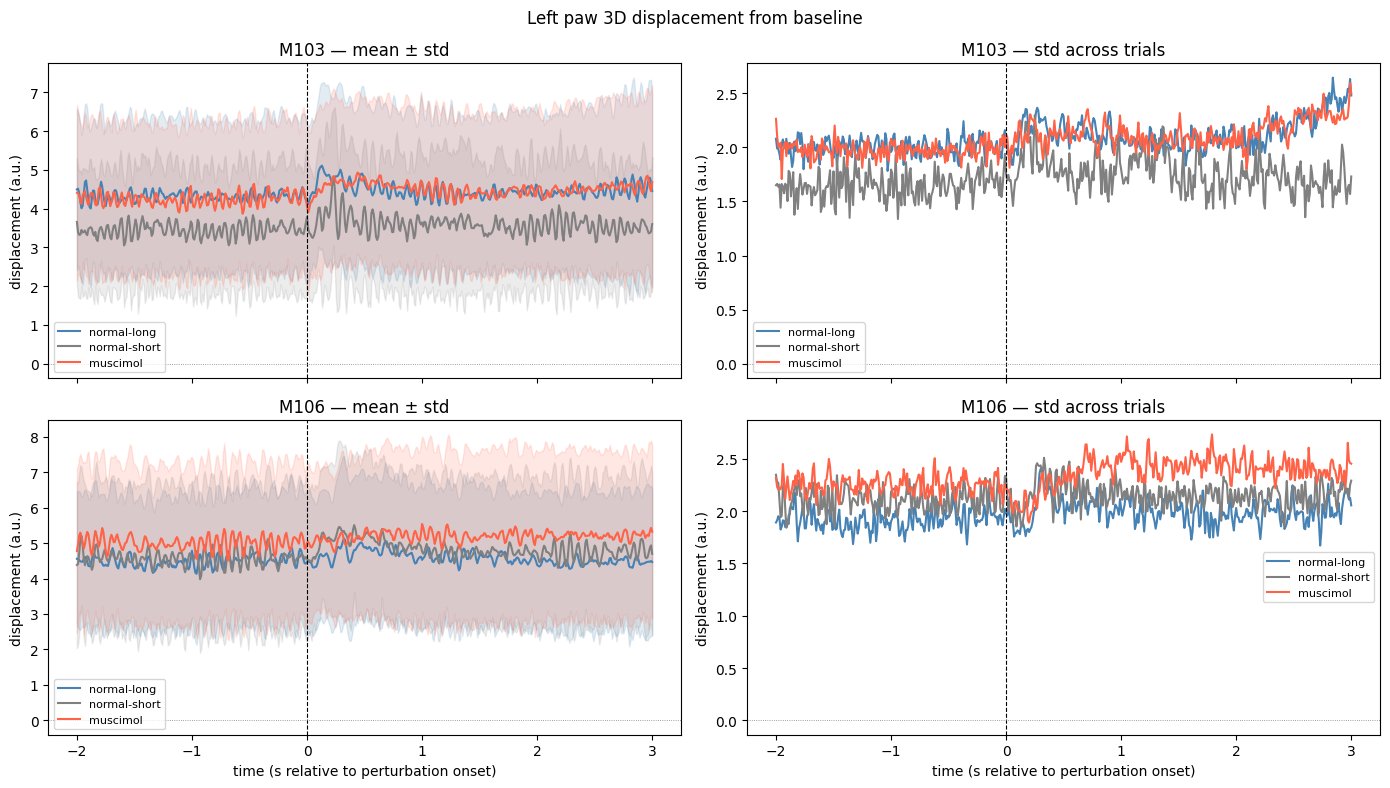

In [5]:
# ── Left paw 3D displacement: mean trajectory and trial variability ────────────
# Metric: Euclidean displacement of left_paw from its baseline mean position.
# Collapses xyz → scalar per timebin, preserving how far the paw moved overall.

left_paw_cols = slice(12, 15)   # bhv cols for left_paw xyz (keypoint 4)
baseline_bins = slice(50, 150)
animals = {
    'M103': {
        'M103_2026_02_18_15_30': 'normal-long',
        'M103_2026_02_19_15_30': 'normal-short',
        'M103_2026_02_20_16_00': 'muscimol',
    },
    'M106': {
        'M106_2026_02_25_15_00': 'normal-long',
        'M106_2026_02_26_16_00': 'normal-short',
        'M106_2026_02_27_16_00': 'muscimol',
    },
}
sess_colors = {'normal-long': 'steelblue', 'normal-short': 'gray', 'muscimol': 'tomato'}

t_axis = (np.arange(501) - 200) * 0.01   # seconds relative to perturbation onset

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)

for row, (animal, sessions) in enumerate(animals.items()):
    ax_mean, ax_std = axes[row, 0], axes[row, 1]

    for sess, label in sessions.items():
        td       = all_sess_no_drop[sess]
        bhv      = np.stack(td.bhv.values)                        # (n_trials, T, 36)
        paw      = bhv[:, :, left_paw_cols]                       # (n_trials, T, 3)
        baseline = paw[:, baseline_bins, :].mean(axis=1, keepdims=True)  # (n_trials, 1, 3)
        disp     = np.linalg.norm(paw - baseline, axis=2)         # (n_trials, T)

        mean = disp.mean(axis=0)
        std  = disp.std(axis=0)
        color = sess_colors[label]

        ax_mean.plot(t_axis, mean, color=color, label=label, linewidth=1.5)
        ax_mean.fill_between(t_axis, mean - std, mean + std, color=color, alpha=0.15)

        ax_std.plot(t_axis, std, color=color, label=label, linewidth=1.5)

        print(f"{animal} | {label}: n={len(td)}, "
              f"mean disp post={mean[200:350].mean():.2f}, "
              f"mean std post={std[200:350].mean():.2f}")

    for ax in (ax_mean, ax_std):
        ax.axvline(0, color='k', linestyle='--', linewidth=0.8)
        ax.axhline(0, color='gray', linestyle=':', linewidth=0.6)
        ax.set_ylabel('displacement (a.u.)')

    ax_mean.set_title(f'{animal} — mean ± std')
    ax_std.set_title(f'{animal} — std across trials')
    ax_mean.legend(fontsize=8)
    ax_std.legend(fontsize=8)

for ax in axes[1]:
    ax.set_xlabel('time (s relative to perturbation onset)')

plt.suptitle('Left paw 3D displacement from baseline')
plt.tight_layout()


In [6]:
Params.oscillating_key_points

['left_ankle',
 'left_elbow',
 'left_foot',
 'left_knee',
 'left_paw',
 'left_wrist',
 'right_ankle',
 'right_elbow',
 'right_foot',
 'right_knee',
 'right_paw',
 'right_wrist']

M103 | normal-long     | n= 24 | paw RMS=0.3966  knee RMS=0.2567  combined=0.3266
M103 | normal-short    | n=  6 | paw RMS=0.3205  knee RMS=0.3006  combined=0.3106
M103 | muscimol        | n= 18 | paw RMS=0.2712  knee RMS=0.2700  combined=0.2706
M106 | normal-long     | n= 17 | paw RMS=0.5614  knee RMS=0.4078  combined=0.4846
M106 | normal-short    | n= 12 | paw RMS=0.3751  knee RMS=0.3241  combined=0.3496
M106 | muscimol        | n= 19 | paw RMS=0.4276  knee RMS=0.3975  combined=0.4125


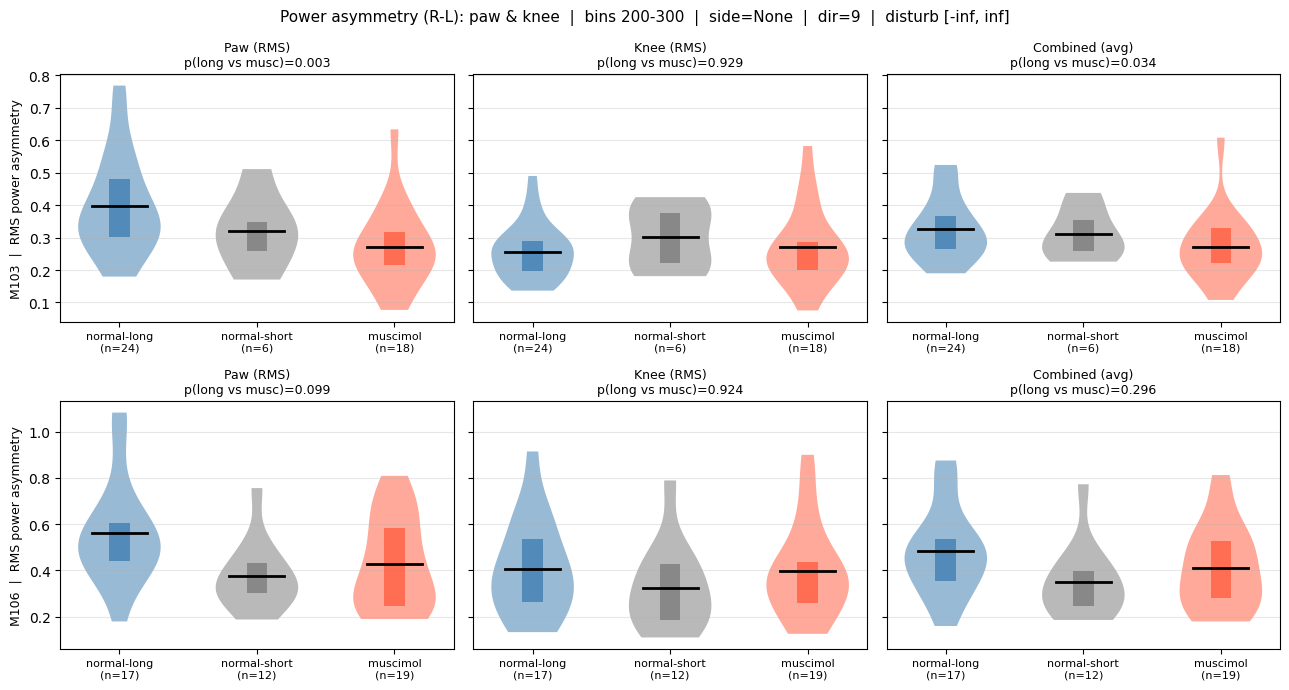


-- Summary (combined score) --
  M103 normal-long      mean=0.3266  median=0.2989  std=0.0954
  M103 normal-short     mean=0.3106  median=0.2869  std=0.0729
  M103 muscimol         mean=0.2706  median=0.2405  std=0.1051
  M106 normal-long      mean=0.4846  median=0.4715  std=0.1852
  M106 normal-short     mean=0.3496  median=0.3063  std=0.1526
  M106 muscimol         mean=0.4125  median=0.4081  std=0.1772


In [7]:
# -- Trial-by-trial power asymmetry: paw + foot pairs --
# Metric: RMS of (right - left) power in post-perturbation window,
# averaged across paw pair (4, 10) and foot pair (3, 9).
# One scalar per trial -> compare distributions across sessions.
#
# Keypoint indices (alphabetical):
#   left_knee=3, left_paw=4, right_knee=9, right_paw=10
#
# Power array per trial: (T=500, 12), onset at bin 200.

import scipy.stats

# -- Parameters --
int_start, int_end = 200, 300      # post-perturbation window (bins); 0-1 s
disturb_lo  = -np.inf              # lower disturb_mean bound
disturb_hi  = np.inf               # upper disturb_mean bound
side        = None                 # None=all, 0=ipsi, 1=contra
sol_direction = 9                  # None=all, or int 0-11 to filter one direction

PAIR_PAW  = (4, 10)   # left_paw, right_paw
PAIR_FOOT = (3, 9)    # left_knee, right_knee

animals = {
    'M103': {
        'M103_2026_02_18_15_30': 'normal-long',
        'M103_2026_02_19_15_30': 'normal-short',
        'M103_2026_02_20_16_00': 'muscimol',
    },
    'M106': {
        'M106_2026_02_25_15_00': 'normal-long',
        'M106_2026_02_26_16_00': 'normal-short',
        'M106_2026_02_27_16_00': 'muscimol',
    },
}
sess_colors = {'normal-long': 'steelblue', 'normal-short': 'gray', 'muscimol': 'tomato'}

# -- Compute per-trial asymmetry scores --
def rms_asym(power_stack, pair, start, end):
    left  = power_stack[:, start:end, pair[0]]
    right = power_stack[:, start:end, pair[1]]
    diff  = right - left
    return np.sqrt((diff ** 2).mean(axis=1))

results = {}
for animal, sess_dict in animals.items():
    for sess, label in sess_dict.items():
        td = all_sess_no_drop.get(sess)
        if td is None:
            print(f'[SKIP] {sess} not loaded')
            continue

        power_stack = np.stack(td['power'].values)
        disturb     = td['disturb_mean'].values

        if side is None:
            side_mask = np.ones(len(td), dtype=bool)
        else:
            side_mask = td['sol_contra_ipsi'].values == side

        if sol_direction is None:
            dir_mask = np.ones(len(td), dtype=bool)
        else:
            dir_mask = td['values_Sol_direction'].values == sol_direction

        mask = (disturb > disturb_lo) & (disturb <= disturb_hi) & side_mask & dir_mask

        rms_paw  = rms_asym(power_stack, PAIR_PAW,  int_start, int_end)[mask]
        rms_foot = rms_asym(power_stack, PAIR_FOOT, int_start, int_end)[mask]
        score    = (rms_paw + rms_foot) / 2.0

        results[sess] = {
            'label':    label,
            'animal':   animal,
            'score':    score,
            'rms_paw':  rms_paw,
            'rms_foot': rms_foot,
            'n':        mask.sum(),
        }
        print(f'{animal} | {label:15s} | n={mask.sum():3d} | '
              f'paw RMS={rms_paw.mean():.4f}  knee RMS={rms_foot.mean():.4f}  '
              f'combined={score.mean():.4f}')

# -- Plot: 2 rows (M103, M106) x 3 columns (paw / knee / combined) --
dir_label = f'dir={sol_direction}' if sol_direction is not None else 'all dirs'
fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharey='row')
fig.suptitle(
    f'Power asymmetry (R-L): paw & knee  |  bins {int_start}-{int_end}  |  '
    f'side={side}  |  {dir_label}  |  disturb [{disturb_lo:.2f}, {disturb_hi:.2f}]',
    fontsize=11
)
col_titles = ['Paw (RMS)', 'Knee (RMS)', 'Combined (avg)']

for row, (animal, sess_dict) in enumerate(animals.items()):
    labels_sorted = ['normal-long', 'normal-short', 'muscimol']
    grp_paw, grp_foot, grp_comb, xlabels = [], [], [], []
    for label in labels_sorted:
        sess = next((s for s, v in results.items()
                     if v['animal'] == animal and v['label'] == label), None)
        if sess is None:
            continue
        r = results[sess]
        grp_paw.append(r['rms_paw'])
        grp_foot.append(r['rms_foot'])
        grp_comb.append(r['score'])
        xlabels.append(label)

    for col, (grps, ctitle) in enumerate(zip(
            [grp_paw, grp_foot, grp_comb], col_titles)):
        ax = axes[row, col]
        colors = [sess_colors[l] for l in xlabels]

        parts = ax.violinplot(grps, positions=range(len(grps)),
                              showmedians=False, showextrema=False, widths=0.6)
        for pc, c in zip(parts['bodies'], colors):
            pc.set_facecolor(c); pc.set_alpha(0.55)

        for i, (grp, c) in enumerate(zip(grps, colors)):
            mean = np.mean(grp)
            q1, q3 = np.percentile(grp, [25, 75])
            ax.plot([i - 0.2, i + 0.2], [mean, mean], color='k', lw=2, zorder=5)
            ax.bar(i, q3 - q1, bottom=q1, width=0.15, color=c,
                   alpha=0.85, zorder=4, linewidth=0)

        if len(grps) == 3:
            stat, p = scipy.stats.mannwhitneyu(grps[0], grps[2], alternative='two-sided')
            ax.set_title(f'{ctitle}\np(long vs musc)={p:.3f}', fontsize=9)
        else:
            ax.set_title(ctitle, fontsize=9)

        ax.set_xticks(range(len(xlabels)))
        ax.set_xticklabels(
            [f'{l}\n(n={len(g)})' for l, g in zip(xlabels, grps)],
            fontsize=8
        )
        if col == 0:
            ax.set_ylabel(f'{animal}  |  RMS power asymmetry', fontsize=9)
        ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# -- Summary stats --
print('\n-- Summary (combined score) --')
for animal, sess_dict in animals.items():
    for label in ['normal-long', 'normal-short', 'muscimol']:
        sess = next((s for s, v in results.items()
                     if v['animal'] == animal and v['label'] == label), None)
        if sess is None:
            continue
        sc = results[sess]['score']
        print(f'  {animal} {label:15s}  mean={sc.mean():.4f}  '
              f'median={np.median(sc):.4f}  std={sc.std():.4f}')


M103 | normal-long     | n=226
M103 | normal-short    | n= 68
M103 | muscimol        | n=223
M106 | normal-long     | n=180
M106 | normal-short    | n=116
M106 | muscimol        | n=247
M103 | normal-long     | paw post-mean = -0.0817
M103 | normal-short    | paw post-mean = -0.0880
M103 | muscimol        | paw post-mean = -0.0533
M106 | normal-long     | paw post-mean = 0.0498
M106 | normal-short    | paw post-mean = 0.0433
M106 | muscimol        | paw post-mean = 0.0579


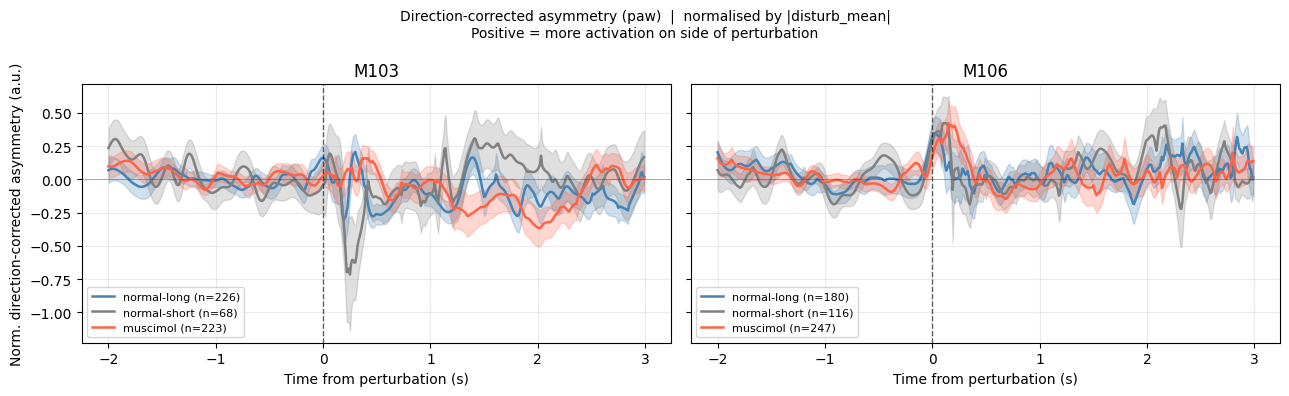


-- Effect sizes (muscimol - normal-long) --
  M103 | ankle   : normal=-0.0569  muscimol=+0.0979  effect=+0.1548
  M103 | elbow   : normal=-0.0124  muscimol=-0.0274  effect=-0.0150
  M103 | foot    : normal=-0.0190  muscimol=-0.0647  effect=-0.0457
  M103 | knee    : normal=-0.1533  muscimol=+0.0782  effect=+0.2315
  M103 | paw     : normal=-0.0817  muscimol=-0.0533  effect=+0.0284
  M103 | wrist   : normal=-0.0821  muscimol=-0.0153  effect=+0.0668
  M106 | ankle   : normal=-0.0164  muscimol=-0.0160  effect=+0.0004
  M106 | elbow   : normal=-0.0553  muscimol=-0.0138  effect=+0.0415
  M106 | foot    : normal=-0.0120  muscimol=+0.0067  effect=+0.0187
  M106 | knee    : normal=+0.0233  muscimol=-0.0076  effect=-0.0310
  M106 | paw     : normal=+0.0498  muscimol=+0.0579  effect=+0.0081
  M106 | wrist   : normal=+0.0287  muscimol=+0.0371  effect=+0.0084

Cross-animal Spearman r=-0.89, p=0.019


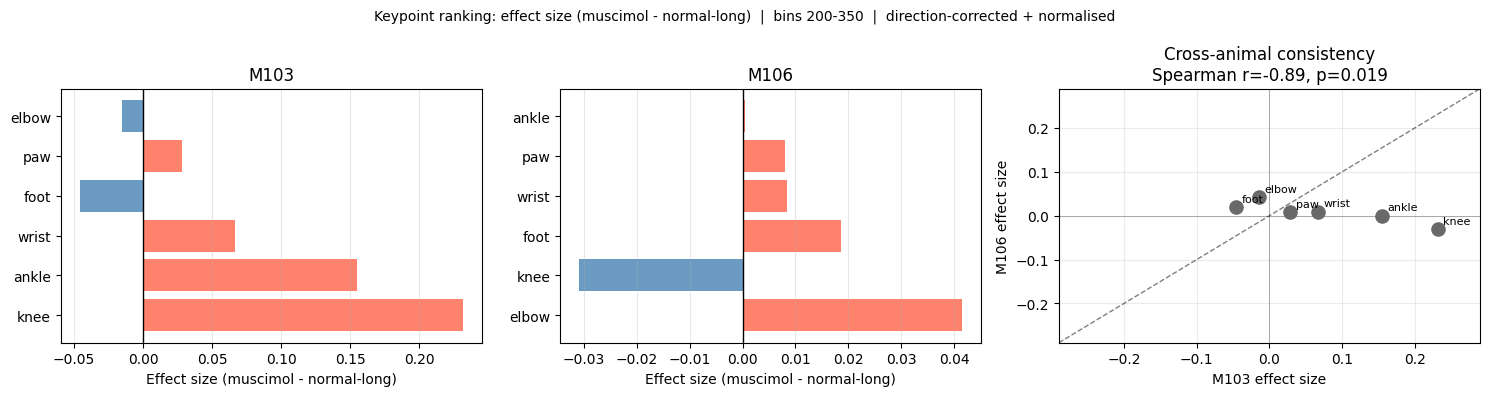

In [8]:
# -- Comprehensive asymmetry analysis --
# Steps:
#   1. Sign-flip ipsi trials -> asymmetry always = compensation toward perturbed side
#   2. Normalise by abs(disturb_mean) per trial
#   3. Fig 1: Time trace (mean +/- SEM) for paw pair, per animal
#   4. Fig 2: Rank all 6 bilateral pairs by effect size (muscimol - normal-long)
#   5. Fig 2 (panel 3): Cross-animal consistency scatter + Spearman r

import scipy.stats

# -- Parameters --
int_start, int_end = 200, 350    # post-perturbation scalar window (bins)
SEM_ALPHA = 0.25

BILATERAL_PAIRS = {
    'ankle': (0, 6),
    'elbow': (1, 7),
    'foot':  (2, 8),
    'knee':  (3, 9),
    'paw':   (4, 10),
    'wrist': (5, 11),
}

animals = {
    'M103': {
        'M103_2026_02_18_15_30': 'normal-long',
        'M103_2026_02_19_15_30': 'normal-short',
        'M103_2026_02_20_16_00': 'muscimol',
    },
    'M106': {
        'M106_2026_02_25_15_00': 'normal-long',
        'M106_2026_02_26_16_00': 'normal-short',
        'M106_2026_02_27_16_00': 'muscimol',
    },
}
sess_colors = {'normal-long': 'steelblue', 'normal-short': 'gray', 'muscimol': 'tomato'}
t_axis = (np.arange(500) - 200) * 0.01   # seconds relative to onset

# -------------------------------------------------------------------------
# Step 1+2: direction-corrected, disturbance-normalised traces
#   diff[trial, t] = (right - left) * direction_sign / |disturb_mean|
#   direction_sign: +1 contra, -1 ipsi  -> positive = compensation toward hit side
# -------------------------------------------------------------------------
def compute_normed_traces(td, pair):
    power_stack = np.stack(td['power'].values)          # (n, T, 12)
    left  = power_stack[:, :, pair[0]]                  # (n, T)
    right = power_stack[:, :, pair[1]]
    diff  = right - left
    direction_sign = np.where(td['sol_contra_ipsi'].values == 1, 1.0, -1.0)
    diff  = diff * direction_sign[:, None]
    disturb_mag = np.clip(np.abs(td['disturb_mean'].values), 1e-6, None)
    diff  = diff / disturb_mag[:, None]
    # baseline-subtract: remove pre-perturbation mean so t<0 is centred at zero
    baseline = diff[:, 50:150].mean(axis=1, keepdims=True)
    diff  = diff - baseline
    return diff   # (n_trials, T)

# Pre-compute all sessions x all pairs
session_data = {}
for animal, sess_dict in animals.items():
    for sess, label in sess_dict.items():
        td = all_sess_no_drop.get(sess)
        if td is None:
            print(f'[SKIP] {sess}')
            continue
        entry = {'label': label, 'animal': animal, 'n': len(td)}
        for kp, pair in BILATERAL_PAIRS.items():
            entry[kp] = compute_normed_traces(td, pair)   # (n, T)
        session_data[sess] = entry
        print(f'{animal} | {label:15s} | n={len(td):3d}')

# -------------------------------------------------------------------------
# Figure 1: Time traces — paw pair, mean +/- SEM, M103 vs M106
# -------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
fig.suptitle(
    'Direction-corrected asymmetry (paw)  |  normalised by |disturb_mean|\n'
    'Positive = more activation on side of perturbation',
    fontsize=10
)

for col, (animal, sess_dict) in enumerate(animals.items()):
    ax = axes[col]
    for label in ['normal-long', 'normal-short', 'muscimol']:
        sess = next((s for s, v in session_data.items()
                     if v['animal'] == animal and v['label'] == label), None)
        if sess is None:
            continue
        traces = session_data[sess]['paw']        # (n, T)
        mean   = traces.mean(axis=0)
        sem    = scipy.stats.sem(traces, axis=0)
        c = sess_colors[label]
        n = session_data[sess]['n']
        ax.plot(t_axis, mean, color=c, lw=1.8, label=f'{label} (n={n})')
        ax.fill_between(t_axis, mean - sem, mean + sem, color=c, alpha=SEM_ALPHA)
        print(f'{animal} | {label:15s} | paw post-mean = {mean[int_start:int_end].mean():.4f}')

    ax.axvline(0, color='k', lw=1, ls='--', alpha=0.6)
    ax.axhline(0, color='k', lw=0.5, alpha=0.4)
    ax.set_title(animal)
    ax.set_xlabel('Time from perturbation (s)')
    if col == 0:
        ax.set_ylabel('Norm. direction-corrected asymmetry (a.u.)')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

# -------------------------------------------------------------------------
# Figure 2: Keypoint ranking + cross-animal consistency
# Scalar = mean of direction-corrected normalised diff over [int_start, int_end]
# Effect size = muscimol_mean - normal_long_mean  (negative = muscimol reduces compensation)
# -------------------------------------------------------------------------
def scalar_score(traces, start, end):
    return traces[:, start:end].mean(axis=1).mean()

kp_names = list(BILATERAL_PAIRS.keys())
all_effects = {animal: {} for animal in animals}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(
    f'Keypoint ranking: effect size (muscimol - normal-long)  |  '
    f'bins {int_start}-{int_end}  |  direction-corrected + normalised',
    fontsize=10
)

print(f'\n-- Effect sizes (muscimol - normal-long) --')
for col, (animal, sess_dict) in enumerate(animals.items()):
    ax = axes[col]

    long_sess = next((s for s, v in session_data.items()
                      if v['animal'] == animal and v['label'] == 'normal-long'), None)
    musc_sess = next((s for s, v in session_data.items()
                      if v['animal'] == animal and v['label'] == 'muscimol'), None)
    if long_sess is None or musc_sess is None:
        continue

    effects = []
    for kp in kp_names:
        score_long = scalar_score(session_data[long_sess][kp], int_start, int_end)
        score_musc = scalar_score(session_data[musc_sess][kp], int_start, int_end)
        effect = score_musc - score_long
        effects.append(effect)
        all_effects[animal][kp] = effect
        print(f'  {animal} | {kp:8s}: normal={score_long:+.4f}  muscimol={score_musc:+.4f}  effect={effect:+.4f}')

    order = np.argsort(np.abs(effects))[::-1]
    ordered_kps = [kp_names[i] for i in order]
    ordered_eff = [effects[i] for i in order]
    bar_colors  = ['tomato' if e > 0 else 'steelblue' for e in ordered_eff]

    ax.barh(ordered_kps, ordered_eff, color=bar_colors, alpha=0.8)
    ax.axvline(0, color='k', lw=1)
    ax.set_title(animal)
    ax.set_xlabel('Effect size (muscimol - normal-long)')
    ax.grid(axis='x', alpha=0.3)

# Panel 3: cross-animal consistency scatter
ax = axes[2]
m103_eff = [all_effects['M103'].get(kp, np.nan) for kp in kp_names]
m106_eff = [all_effects['M106'].get(kp, np.nan) for kp in kp_names]

ax.scatter(m103_eff, m106_eff, s=90, zorder=3, color='dimgray')
for i, kp in enumerate(kp_names):
    ax.annotate(kp, (m103_eff[i], m106_eff[i]), fontsize=8,
                xytext=(4, 4), textcoords='offset points')

lim = max(np.nanmax(np.abs(m103_eff)), np.nanmax(np.abs(m106_eff))) * 1.25
ax.plot([-lim, lim], [-lim, lim], 'k--', lw=1, alpha=0.5, label='unity')
ax.axhline(0, color='k', lw=0.5, alpha=0.4)
ax.axvline(0, color='k', lw=0.5, alpha=0.4)
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
ax.set_xlabel('M103 effect size')
ax.set_ylabel('M106 effect size')
ax.grid(alpha=0.25)

valid_pairs = [(x, y) for x, y in zip(m103_eff, m106_eff)
               if not (np.isnan(x) or np.isnan(y))]
if len(valid_pairs) >= 3:
    r, p = scipy.stats.spearmanr([v[0] for v in valid_pairs], [v[1] for v in valid_pairs])
    ax.set_title(f'Cross-animal consistency\nSpearman r={r:.2f}, p={p:.3f}')
    print(f'\nCross-animal Spearman r={r:.2f}, p={p:.3f}')
else:
    ax.set_title('Cross-animal consistency')

plt.tight_layout()
plt.show()


Tertile edges (disturb_mean): -0.293  -0.169
Pooled n=1060  bin sizes (expected ~353 each)

M103 | normal-long     | bin 0 | n= 44  ret= 39  median=0.750s  nan=  5
M103 | normal-long     | bin 1 | n= 66  ret= 61  median=0.460s  nan=  5
M103 | normal-long     | bin 2 | n=117  ret=111  median=0.410s  nan=  6
M103 | normal-short    | bin 0 | n= 11  ret= 10  median=0.640s  nan=  1
M103 | normal-short    | bin 1 | n= 31  ret= 31  median=0.730s  nan=  0
M103 | normal-short    | bin 2 | n= 26  ret= 25  median=0.310s  nan=  1
M103 | muscimol        | bin 0 | n= 85  ret= 70  median=0.980s  nan= 15
M103 | muscimol        | bin 1 | n= 98  ret= 91  median=0.640s  nan=  7
M103 | muscimol        | bin 2 | n= 40  ret= 35  median=0.450s  nan=  5
M106 | normal-long     | bin 0 | n= 96  ret= 87  median=0.610s  nan=  9
M106 | normal-long     | bin 1 | n= 50  ret= 47  median=0.490s  nan=  3
M106 | normal-long     | bin 2 | n= 34  ret= 33  median=0.210s  nan=  1
M106 | normal-short    | bin 0 | n= 33  ret=

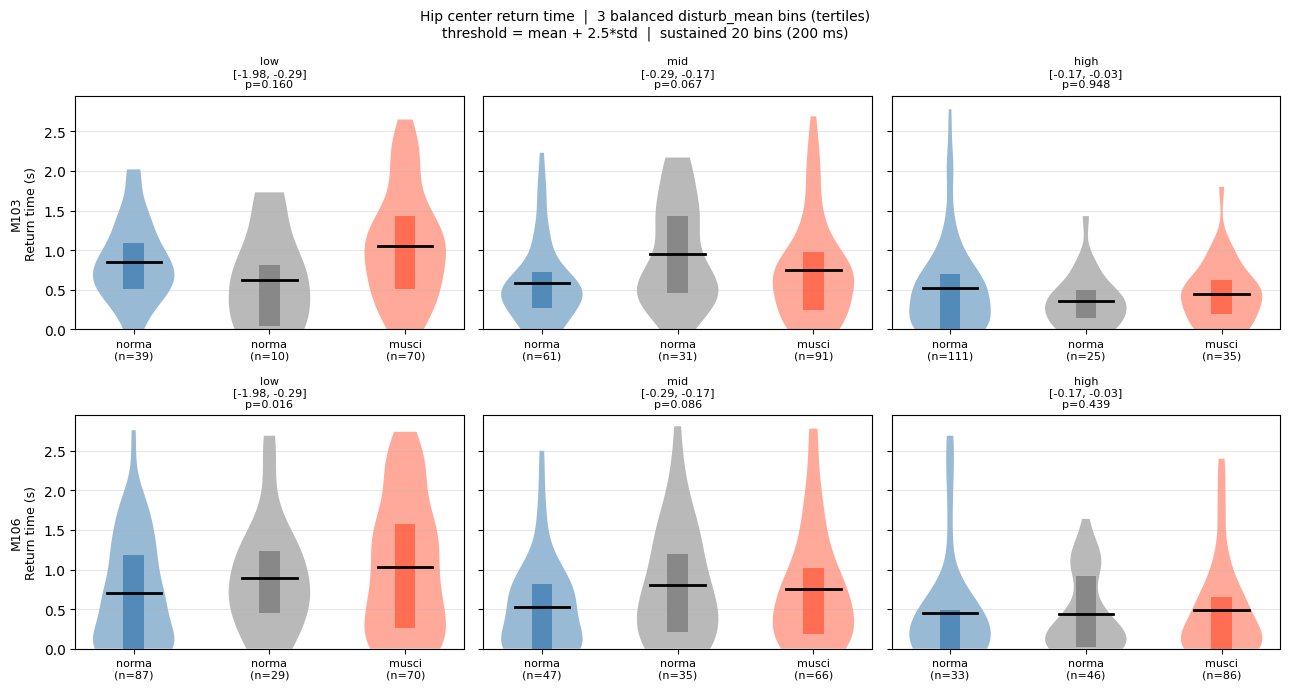

In [9]:
# -- Hip center return time: binned by disturb_mean (3 balanced bins) --
# Bin edges from tertiles of pooled disturb_mean across all sessions,
# so bins are defined consistently and roughly equally populated.
# Layout: 2 rows (M103, M106) x 3 cols (low / mid / high disturb_mean).
# Each subplot: violin per condition (normal-long, normal-short, muscimol).

import scipy.stats

# -- Parameters --
ONSET_BIN    = 200
n_consec     = 20
thresh_sigma = 2.5

sess_map = {
    'M103': {
        'M103_2026_02_18_15_30': 'normal-long',
        'M103_2026_02_19_15_30': 'normal-short',
        'M103_2026_02_20_16_00': 'muscimol',
    },
    'M106': {
        'M106_2026_02_25_15_00': 'normal-long',
        'M106_2026_02_26_16_00': 'normal-short',
        'M106_2026_02_27_16_00': 'muscimol',
    },
}
sess_colors  = {'normal-long': 'steelblue', 'normal-short': 'gray', 'muscimol': 'tomato'}
labels_order = ['normal-long', 'normal-short', 'muscimol']

# -- Step 1: compute tertile bin edges from pooled disturb_mean --
all_disturb = np.concatenate([
    all_sess_no_drop[sess]['disturb_mean'].values
    for sess_dict in sess_map.values()
    for sess in sess_dict
    if sess in all_sess_no_drop
])
edges = np.quantile(all_disturb, [0, 1/3, 2/3, 1])
bin_labels = [
    f'low\n[{edges[0]:.2f}, {edges[1]:.2f}]',
    f'mid\n[{edges[1]:.2f}, {edges[2]:.2f}]',
    f'high\n[{edges[2]:.2f}, {edges[3]:.2f}]',
]
print(f'Tertile edges (disturb_mean): {edges[1]:.3f}  {edges[2]:.3f}')
print(f'Pooled n={len(all_disturb)}  '
      f'bin sizes (expected ~{len(all_disturb)//3} each)\n')

# -- Step 2: return time function --
def compute_return_times(td, d_lo, d_hi, onset=ONSET_BIN,
                         n_consec=20, thresh_sigma=2.5):
    disturb = td['disturb_mean'].values
    # include upper edge in last bin
    mask = (disturb >= d_lo) & (disturb <= d_hi)
    td_sel = td[mask]
    if len(td_sel) == 0:
        return np.array([]), 0

    hip = np.stack(td_sel['hip_center'].values)               # (n, T, 3)
    baseline_pos = hip[:, 50:150, :].mean(axis=1, keepdims=True)
    dist = np.linalg.norm(hip - baseline_pos, axis=2)         # (n, T)
    bl_mean = dist[:, 50:150].mean(axis=1)
    bl_std  = dist[:, 50:150].std(axis=1)
    thresh  = bl_mean + thresh_sigma * bl_std

    return_times = []
    for i in range(len(td_sel)):
        post  = dist[i, onset:]
        below = post < thresh[i]
        ret_bin, count = None, 0
        for t, b in enumerate(below):
            if b:
                count += 1
                if count >= n_consec:
                    ret_bin = t - n_consec + 1
                    break
            else:
                count = 0
        return_times.append(ret_bin * 0.01 if ret_bin is not None else np.nan)
    return np.array(return_times), mask.sum()

# -- Step 3: compute return times per session x bin --
# rt_data[(animal, label, bin_idx)] = array of return times
rt_data = {}
for animal, sess_dict in sess_map.items():
    for sess, label in sess_dict.items():
        td = all_sess_no_drop.get(sess)
        if td is None:
            print(f'[SKIP] {sess}')
            continue
        for b, (d_lo, d_hi) in enumerate(zip(edges[:-1], edges[1:])):
            rt, n_sel = compute_return_times(
                td, d_lo, d_hi,
                onset=ONSET_BIN, n_consec=n_consec, thresh_sigma=thresh_sigma
            )
            rt_data[(animal, label, b)] = rt
            n_valid = np.sum(~np.isnan(rt))
            print(f'{animal} | {label:15s} | bin {b} | '
                  f'n={n_sel:3d}  ret={n_valid:3d}  '
                  f'median={np.nanmedian(rt):.3f}s  '
                  f'nan={np.sum(np.isnan(rt)):3d}')

# -- Step 4: plot 2 rows (animals) x 3 cols (bins) --
n_bins = 3
fig, axes = plt.subplots(2, n_bins, figsize=(13, 7), sharey=True)
fig.suptitle(
    f'Hip center return time  |  3 balanced disturb_mean bins (tertiles)\n'
    f'threshold = mean + {thresh_sigma}*std  |  sustained {n_consec} bins ({n_consec*10} ms)',
    fontsize=10
)

for row, (animal, sess_dict) in enumerate(sess_map.items()):
    for b, blabel in enumerate(bin_labels):
        ax = axes[row, b]
        grps = [rt_data.get((animal, l, b), np.array([])) for l in labels_order]
        grps_valid = [g[~np.isnan(g)] if len(g) > 0 else np.array([]) for g in grps]
        colors = [sess_colors[l] for l in labels_order]

        non_empty = [g for g in grps_valid if len(g) > 1]
        positions = [i for i, g in enumerate(grps_valid) if len(g) > 1]
        if non_empty:
            parts = ax.violinplot(non_empty, positions=positions,
                                  showmedians=False, showextrema=False, widths=0.6)
            for pc, pos in zip(parts['bodies'], positions):
                pc.set_facecolor(colors[pos]); pc.set_alpha(0.55)

        for i, (grp, c) in enumerate(zip(grps_valid, colors)):
            if len(grp) == 0:
                continue
            mean_val = np.mean(grp)
            q1, q3   = np.percentile(grp, [25, 75])
            ax.plot([i - 0.2, i + 0.2], [mean_val, mean_val], color='k', lw=2, zorder=5)
            ax.bar(i, q3 - q1, bottom=q1, width=0.15, color=c,
                   alpha=0.85, zorder=4, linewidth=0)

        ax.set_xticks(range(len(labels_order)))
        ax.set_xticklabels(
            [f'{l[:5]}\n(n={len(g)})' for l, g in zip(labels_order, grps_valid)],
            fontsize=8
        )
        if b == 0:
            ax.set_ylabel(f'{animal}\nReturn time (s)', fontsize=9)
        if row == 0:
            ax.set_title(blabel, fontsize=9)
        ax.grid(axis='y', alpha=0.3)

        # Mann-Whitney: normal-long vs muscimol
        g_long = grps_valid[0]; g_musc = grps_valid[2]
        if len(g_long) > 1 and len(g_musc) > 1:
            _, p = scipy.stats.mannwhitneyu(g_long, g_musc, alternative='two-sided')
            ax.set_title(f'{blabel}\np={p:.3f}', fontsize=8)

plt.tight_layout()
plt.show()


disturb_mean filter: [-1, -0.05]

M103 normal-long     | selected=219  returned=215  median=0.090s  nan=  4
M103 normal-short    | selected= 67  returned= 67  median=0.340s  nan=  0
M103 muscimol        | selected=219  returned=209  median=0.350s  nan= 10
M106 normal-long     | selected=163  returned=162  median=0.000s  nan=  1
M106 normal-short    | selected=114  returned=113  median=0.080s  nan=  1
M106 muscimol        | selected=224  returned=220  median=0.060s  nan=  4

-- Mann-Whitney (normal-long vs muscimol, per animal) --
  M103: p=0.000  normal-long median=0.090s  muscimol median=0.350s
  M106: p=0.000  normal-long median=0.000s  muscimol median=0.060s
-- Mann-Whitney (M103 vs M106 within condition) --
  normal-long    : p=0.000  M103 median=0.090s  M106 median=0.000s
  normal-short   : p=0.011  M103 median=0.340s  M106 median=0.080s
  muscimol       : p=0.000  M103 median=0.350s  M106 median=0.060s


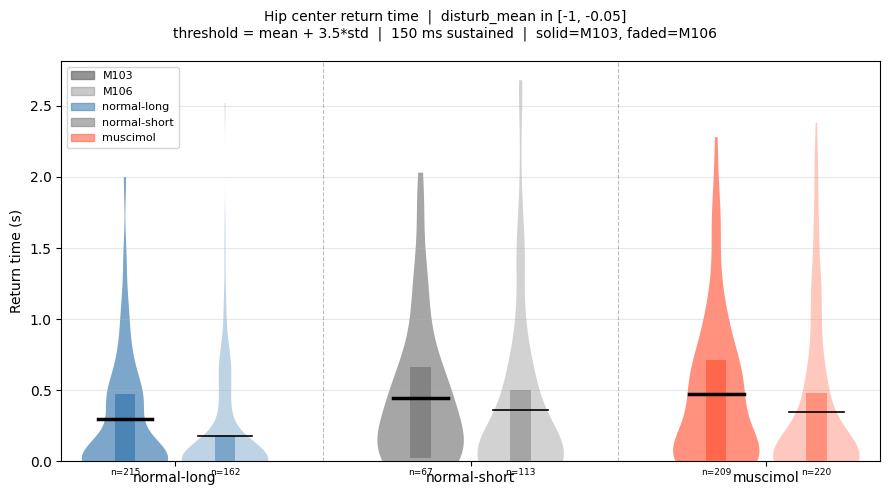

In [628]:
# -- Hip return time: both animals overlapped, disturb_mean in [-1, -0.3] --
# 6 violins grouped by condition (normal-long / normal-short / muscimol),
# M103 solid, M106 faded. Gap between condition groups.

import scipy.stats
import matplotlib.patches as mpatches

# -- Parameters --
D_LO, D_HI  = -1, -0.05
ONSET_BIN   = 200
n_consec    = 15
thresh_sigma = 3.5

sess_info = {
    'M103': {
        'normal-long':  'M103_2026_02_18_15_30',
        'normal-short': 'M103_2026_02_19_15_30',
        'muscimol':     'M103_2026_02_20_16_00',
    },
    'M106': {
        'normal-long':  'M106_2026_02_25_15_00',
        'normal-short': 'M106_2026_02_26_16_00',
        'muscimol':     'M106_2026_02_27_16_00',
    },
}
cond_colors  = {'normal-long': 'steelblue', 'normal-short': 'gray', 'muscimol': 'tomato'}
conds_order  = ['normal-long', 'normal-short', 'muscimol']
animal_alpha = {'M103': 0.7, 'M106': 0.35}
animal_lw    = {'M103': 2.5, 'M106': 1.2}

def hip_return_times(td, d_lo, d_hi, onset, n_consec, thresh_sigma):
    disturb = td['disturb_mean'].values
    mask    = (disturb >= d_lo) & (disturb <= d_hi)
    td_sel  = td[mask]
    if len(td_sel) == 0:
        return np.array([]), 0
    hip = np.stack(td_sel['hip_center'].values)
    bpos = hip[:, 50:150, :].mean(axis=1, keepdims=True)
    dist = np.linalg.norm(hip - bpos, axis=2)
    thresh = dist[:, 50:150].mean(axis=1) + thresh_sigma * dist[:, 50:150].std(axis=1)
    rts = []
    for i in range(len(td_sel)):
        below = dist[i, onset:] < thresh[i]
        ret_bin, count = None, 0
        for t, b in enumerate(below):
            count = count + 1 if b else 0
            if count >= n_consec:
                ret_bin = t - n_consec + 1; break
        rts.append(ret_bin * 0.01 if ret_bin is not None else np.nan)
    return np.array(rts), mask.sum()

# -- Compute --
rt = {}
print(f'disturb_mean filter: [{D_LO}, {D_HI}]\n')
for animal, conds in sess_info.items():
    for cond, sess in conds.items():
        td = all_sess_no_drop.get(sess)
        if td is None:
            print(f'[SKIP] {sess}'); continue
        arr, n_sel = hip_return_times(td, D_LO, D_HI, ONSET_BIN, n_consec, thresh_sigma)
        valid = arr[~np.isnan(arr)]
        rt[(animal, cond)] = valid
        print(f'{animal} {cond:15s} | selected={n_sel:3d}  '
              f'returned={len(valid):3d}  '
              f'median={np.nanmedian(arr):.3f}s  '
              f'nan={np.isnan(arr).sum():3d}')

# -- Positions: within each condition group, M103 left / M106 right --
# Groups at x = 0, 1.3, 2.6; within each group offset by 0.45
group_centers = {c: i * 1.3 for i, c in enumerate(conds_order)}
offsets = {'M103': -0.22, 'M106': +0.22}
pos = {(a, c): group_centers[c] + offsets[a]
       for a in ['M103', 'M106'] for c in conds_order}

xtick_pos    = list(group_centers.values())
xtick_labels = conds_order

fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle(
    f'Hip center return time  |  disturb_mean in [{D_LO}, {D_HI}]\n'
    f'threshold = mean + {thresh_sigma}*std  |  {n_consec*10} ms sustained  |  '
    f'solid=M103, faded=M106',
    fontsize=10
)

for (animal, cond), grp in rt.items():
    if len(grp) < 2:
        continue
    p = pos[(animal, cond)]
    c = cond_colors[cond]
    alpha = animal_alpha[animal]
    lw    = animal_lw[animal]

    parts = ax.violinplot([grp], positions=[p],
                          showmedians=False, showextrema=False, widths=0.38)
    for pc in parts['bodies']:
        pc.set_facecolor(c); pc.set_alpha(alpha)

    mean_val = np.mean(grp)
    q1, q3   = np.percentile(grp, [25, 75])
    ax.plot([p - 0.12, p + 0.12], [mean_val, mean_val], color='k', lw=lw, zorder=5)
    ax.bar(p, q3 - q1, bottom=q1, width=0.09, color=c,
           alpha=min(alpha + 0.2, 1), zorder=4, linewidth=0)
    ax.text(p, -0.05, f'n={len(grp)}', ha='center', va='top', fontsize=6.5)

# dividers between condition groups
for x in [0.65, 1.95]:
    ax.axvline(x, color='k', lw=0.8, ls='--', alpha=0.25)

ax.set_xticks(xtick_pos)
ax.set_xticklabels(xtick_labels, fontsize=10)
ax.set_xlim(-0.5, 3.1)
ax.set_ylabel('Return time (s)')
ax.grid(axis='y', alpha=0.3)

handles = [
    mpatches.Patch(color='dimgray', alpha=0.7,  label='M103'),
    mpatches.Patch(color='dimgray', alpha=0.35, label='M106'),
    mpatches.Patch(color='steelblue', alpha=0.6, label='normal-long'),
    mpatches.Patch(color='gray',      alpha=0.6, label='normal-short'),
    mpatches.Patch(color='tomato',    alpha=0.6, label='muscimol'),
]
ax.legend(handles=handles, fontsize=8, loc='upper left')

# -- Stats --
print('\n-- Mann-Whitney (normal-long vs muscimol, per animal) --')
for animal in ['M103', 'M106']:
    g1 = rt.get((animal, 'normal-long'), np.array([]))
    g2 = rt.get((animal, 'muscimol'),    np.array([]))
    if len(g1) > 1 and len(g2) > 1:
        _, p = scipy.stats.mannwhitneyu(g1, g2, alternative='two-sided')
        print(f'  {animal}: p={p:.3f}  '
              f'normal-long median={np.median(g1):.3f}s  '
              f'muscimol median={np.median(g2):.3f}s')

print('-- Mann-Whitney (M103 vs M106 within condition) --')
for cond in conds_order:
    g1 = rt.get(('M103', cond), np.array([]))
    g2 = rt.get(('M106', cond), np.array([]))
    if len(g1) > 1 and len(g2) > 1:
        _, p = scipy.stats.mannwhitneyu(g1, g2, alternative='two-sided')
        print(f'  {cond:15s}: p={p:.3f}  '
              f'M103 median={np.median(g1):.3f}s  '
              f'M106 median={np.median(g2):.3f}s')

plt.tight_layout()
plt.show()


In [5]:
# -- Hip return time: both animals overlapped, disturb_mean in [-1, -0.3] --
# 4 violins grouped by condition (normal-long / muscimol),
# M103 solid, M106 hatched. Gap between condition groups.

import scipy.stats

# -- Parameters --
D_LO, D_HI  = -0.7, -0.3
ONSET_BIN   = 200
n_consec    = 18
thresh_sigma = 3

sess_info = {
    'M103': {
        'normal-long': 'M103_2026_02_18_15_30',
        'muscimol':    'M103_2026_02_20_16_00',
    },
    'M106': {
        'normal-long': 'M106_2026_02_25_15_00',
        'muscimol':    'M106_2026_02_27_16_00',
    },
}
cond_colors = {'normal-long': 'steelblue', 'muscimol': 'tomato'}
animal_alpha = {'M103': 0.7, 'M106': 0.35}
animal_lw    = {'M103': 2.5, 'M106': 1.2}

def hip_return_times(td, d_lo, d_hi, onset, n_consec, thresh_sigma):
    disturb = td['disturb_mean'].values
    mask    = (disturb >= d_lo) & (disturb <= d_hi)
    td_sel  = td[mask]
    if len(td_sel) == 0:
        return np.array([]), 0
    hip = np.stack(td_sel['hip_center'].values)
    bpos = hip[:, 50:180, :].mean(axis=1, keepdims=True)
    dist = np.linalg.norm(hip - bpos, axis=2)
    thresh = dist[:, 50:180].mean(axis=1) + thresh_sigma * dist[:, 50:180].std(axis=1)
    rts = []
    for i in range(len(td_sel)):
        below = dist[i, onset:] < thresh[i]
        ret_bin, count = None, 0
        for t, b in enumerate(below):
            count = count + 1 if b else 0
            if count >= n_consec:
                ret_bin = t - n_consec + 1; break
        rts.append(ret_bin * 0.01 if ret_bin is not None else np.nan)
    return np.array(rts), mask.sum()

# -- Compute --
rt = {}  # (animal, cond) -> valid return times
print(f'disturb_mean filter: [{D_LO}, {D_HI}]\n')
for animal, conds in sess_info.items():
    for cond, sess in conds.items():
        td = all_sess_no_drop.get(sess)
        if td is None:
            print(f'[SKIP] {sess}'); continue
        arr, n_sel = hip_return_times(td, D_LO, D_HI, ONSET_BIN, n_consec, thresh_sigma)
        valid = arr[~np.isnan(arr)]
        rt[(animal, cond)] = valid
        print(f'{animal} {cond:15s} | selected={n_sel:3d}  '
              f'returned={len(valid):3d}  '
              f'median={np.nanmedian(arr):.3f}s  '
              f'nan={np.isnan(arr).sum():3d}')

# -- Plot --



disturb_mean filter: [-0.7, -0.3]

M103 normal-long     | selected= 36  returned= 35  median=0.530s  nan=  1
M103 muscimol        | selected= 74  returned= 66  median=0.730s  nan=  8
M106 normal-long     | selected= 72  returned= 71  median=0.150s  nan=  1
M106 muscimol        | selected= 54  returned= 50  median=0.495s  nan=  4


In [ ]:
from tools.viz.rc_style import rc_context_talk
from pathlib import Path

C_NORMAL      = plt.cm.bwr(0.2)  # violin fill — control
C_MUSCIMOL    = "#6D6D6D"         # violin fill — muscimol
C_LINE_DOT    = "#b8b7b7"         # connecting lines + dots

_PDF_DIR = Path('../../results/pdfs')

pooled = {}
for (animal, cond), grp in rt.items():
    pooled.setdefault(cond, []).extend(grp)

conditions       = ['normal-long', 'muscimol']
cond_colors      = {'normal-long': C_NORMAL,  'muscimol': C_MUSCIMOL}
cond_line_colors = {'normal-long': 'k',        'muscimol': 'k'}
cond_labels      = {'normal-long': 'Control',  'muscimol': 'Muscimol'}
xpos             = {'normal-long': 0, 'muscimol': 1}
animal_alpha     = {'M103': 0.9, 'M106': 0.9}

# fixed y limits across all frames
_all_vals = [v for grp in pooled.values() for v in grp]
# _ylim = (min(_all_vals) * 0.95, max(_all_vals) * 1.05)
_ylim = (0, 1)

_frames = [
    (1, False, 'muscimol_frame1_control'),
    (2, False, 'muscimol_frame2_both'),
    (2, True,  'muscimol_frame3_individuals'),
]

for n_conds, show_individuals, save_name in _frames:
    shown = conditions[:n_conds]
    with rc_context_talk():
        fig, ax = plt.subplots(figsize=(3, 3))

        for cond in shown:
            grp = pooled.get(cond, [])
            if len(grp) < 2:
                continue
            p  = xpos[cond]
            c  = cond_colors[cond]
            lc = cond_line_colors[cond]

            parts = ax.violinplot([grp], positions=[p],
                                  showmedians=False, showextrema=False, widths=0.55)
            for pc in parts['bodies']:
                pc.set_facecolor(c)
                pc.set_alpha(0.85)
                pc.set_edgecolor('none')

            mean_val = np.mean(grp)
            ax.plot([p - 0.14, p + 0.14], [mean_val, mean_val],
                    color=lc, lw=2.5, zorder=5, solid_capstyle='round')

        if show_individuals:
            for animal, alpha in animal_alpha.items():
                xs    = [xpos[cond] for cond in shown if len(rt.get((animal, cond), [])) > 0]
                means = [np.mean(rt[(animal, cond)]) for cond in shown if len(rt.get((animal, cond), [])) > 0]
                ax.plot(xs, means, '-o', color=C_LINE_DOT, alpha=alpha,
                        lw=1.5, markersize=5, zorder=6, markeredgewidth=0)

        ax.set_xticks([0, 1])
        ax.set_xticklabels([cond_labels[c] for c in conditions])
        ax.set_xlim(-0.55, 1.55)
        ax.set_ylim(_ylim)
        ax.set_ylabel('Return time (s)')
        ax.set_title('Centre-of-mass\nreturn time')

        plt.tight_layout()
        out = _PDF_DIR / f'{save_name}.pdf'
        # fig.savefig(out, bbox_inches='tight')
        print(f'Saved: {out}')
        plt.show()

print('\n-- Mann-Whitney (control vs muscimol, pooled) --')
g1 = pooled.get('normal-long', [])
g2 = pooled.get('muscimol', [])
if len(g1) > 1 and len(g2) > 1:
    _, p_val = scipy.stats.mannwhitneyu(g1, g2, alternative='two-sided')
    print(f'  pooled: p={p_val:.3f}  '
          f'control median={np.median(g1):.3f}s  '
          f'muscimol median={np.median(g2):.3f}s')

print('\n-- Mann-Whitney per animal --')
for animal in ['M103', 'M106']:
    g1 = rt.get((animal, 'normal-long'), np.array([]))
    g2 = rt.get((animal, 'muscimol'),    np.array([]))
    if len(g1) > 1 and len(g2) > 1:
        _, p_val = scipy.stats.mannwhitneyu(g1, g2, alternative='two-sided')
        print(f'  {animal}: p={p_val:.3f}  '
              f'control median={np.median(g1):.3f}s  '
              f'muscimol median={np.median(g2):.3f}s')


Saved: ../../results/pdfs/muscimol_return_time.pdf


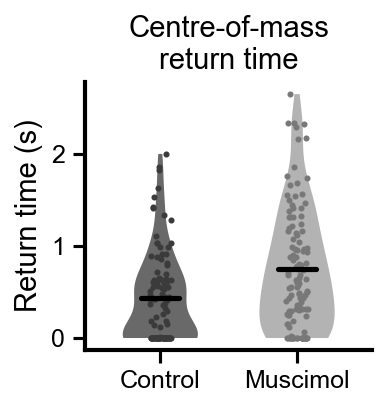

In [12]:
from tools.viz.rc_style import rc_context_talk
from pathlib import Path

C_NORMAL   = "#4F4F4F"
C_NORMAL_scatter   = "#3C3B3B"
C_MUSCIMOL = "#A6A6A6"
C_MUSCIMOL_scatter = "#797878"
C_LINE_DOT = "#b8b7b7"
_PDF_DIR   = Path('../../results/pdfs')

pooled = {}
for (animal, cond), grp in rt.items():
    pooled.setdefault(cond, []).extend(grp)

conditions   = ['normal-long', 'muscimol']
cond_colors  = {'normal-long': C_NORMAL, 'muscimol': C_MUSCIMOL}
cond_colors_scatter  = {'normal-long': C_NORMAL_scatter, 'muscimol': C_MUSCIMOL_scatter}

cond_labels  = {'normal-long': 'Control', 'muscimol': 'Muscimol'}
xpos         = {'normal-long': 0, 'muscimol': 1}
animal_alpha = {'M103': 0.9, 'M106': 0.9}

_ylim = (0, 1)
rng = np.random.default_rng(42)

with rc_context_talk():
    fig, ax = plt.subplots(figsize=(3, 3))

    for cond in conditions:
        grp = pooled.get(cond, [])
        if len(grp) < 2:
            continue
        p = xpos[cond]
        c = cond_colors[cond]
        c_scatter = cond_colors_scatter[cond]

        # violin
        parts = ax.violinplot([grp], positions=[p],
                              showmedians=False, showextrema=False, widths=0.55)
        for pc in parts['bodies']:
            pc.set_facecolor(c)
            pc.set_alpha(0.85)
            pc.set_edgecolor('none')

        # mean line
        ax.plot([p - 0.14, p + 0.14], [np.mean(grp)] * 2,
                color='k', lw=2.5, zorder=5, solid_capstyle='round')

        # jittered dots
        jitter = rng.uniform(-0.08, 0.08, size=len(grp))
        ax.scatter(p + jitter, grp, s=2, color=c_scatter)

        # n= annotation
        # ax.text(p, _ylim[0] - 0.04, f'n={len(grp)}',
        #         ha='center', va='top', fontsize=7, color='#555555')

    # individual animal mean lines
    # for animal, alpha in animal_alpha.items():
    #     xs    = [xpos[cond] for cond in conditions if len(rt.get((animal, cond), [])) > 0]
    #     means = [np.mean(rt[(animal, cond)]) for cond in conditions if len(rt.get((animal, cond), [])) > 0]
    #     ax.plot(xs, means, '-o', color=C_LINE_DOT, alpha=alpha,
    #             lw=1.5, markersize=5, zorder=6, markeredgewidth=0)

    # p-value bracket
    # g1, g2 = pooled.get('normal-long', []), pooled.get('muscimol', [])
    # if len(g1) > 1 and len(g2) > 1:
    #     _, p_val = scipy.stats.mannwhitneyu(g1, g2, alternative='two-sided')
    #     sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'
    #     y_br = _ylim[1] * 0.93
    #     ax.plot([0, 0, 1, 1], [y_br - 0.03, y_br, y_br, y_br - 0.03], lw=1, color='k')
    #     ax.text(0.5, y_br + 0.01, sig, ha='center', va='bottom', fontsize=9)
    #     print(f'MW p={p_val:.3f}  control median={np.median(g1):.3f}s  muscimol median={np.median(g2):.3f}s')

    ax.set_xticks([0, 1])
    ax.set_xticklabels([cond_labels[c] for c in conditions])
    ax.set_xlim(-0.55, 1.55)
    # ax.set_ylim(_ylim)
    ax.set_ylabel('Return time (s)')
    ax.set_title('Centre-of-mass\nreturn time')

    plt.tight_layout()
    out = _PDF_DIR / 'muscimol_return_time.pdf'
    # fig.savefig(out, bbox_inches='tight')
    print(f'Saved: {out}')
    fig.savefig('../../results/pdfs/muscimol.svg', bbox_inches='tight')

    plt.show()


sigma=1.5  ctrl_med=0.845s  musc_med=1.320s  nan_ctrl=11.1%  nan_musc=35.7%  p=0.007
sigma=2.0  ctrl_med=0.665s  musc_med=0.940s  nan_ctrl=3.5%  nan_musc=19.1%  p=0.005
sigma=2.5  ctrl_med=0.580s  musc_med=0.810s  nan_ctrl=2.8%  nan_musc=12.3%  p=0.001
sigma=3.0  ctrl_med=0.375s  musc_med=0.615s  nan_ctrl=2.1%  nan_musc=9.1%  p=0.000
sigma=3.5  ctrl_med=0.115s  musc_med=0.440s  nan_ctrl=2.1%  nan_musc=8.4%  p=0.001
sigma=4.0  ctrl_med=0.000s  musc_med=0.380s  nan_ctrl=0.0%  nan_musc=5.5%  p=0.000
sigma=4.5  ctrl_med=0.000s  musc_med=0.320s  nan_ctrl=0.0%  nan_musc=3.5%  p=0.000
sigma=5.0  ctrl_med=0.000s  musc_med=0.225s  nan_ctrl=0.0%  nan_musc=3.5%  p=0.000


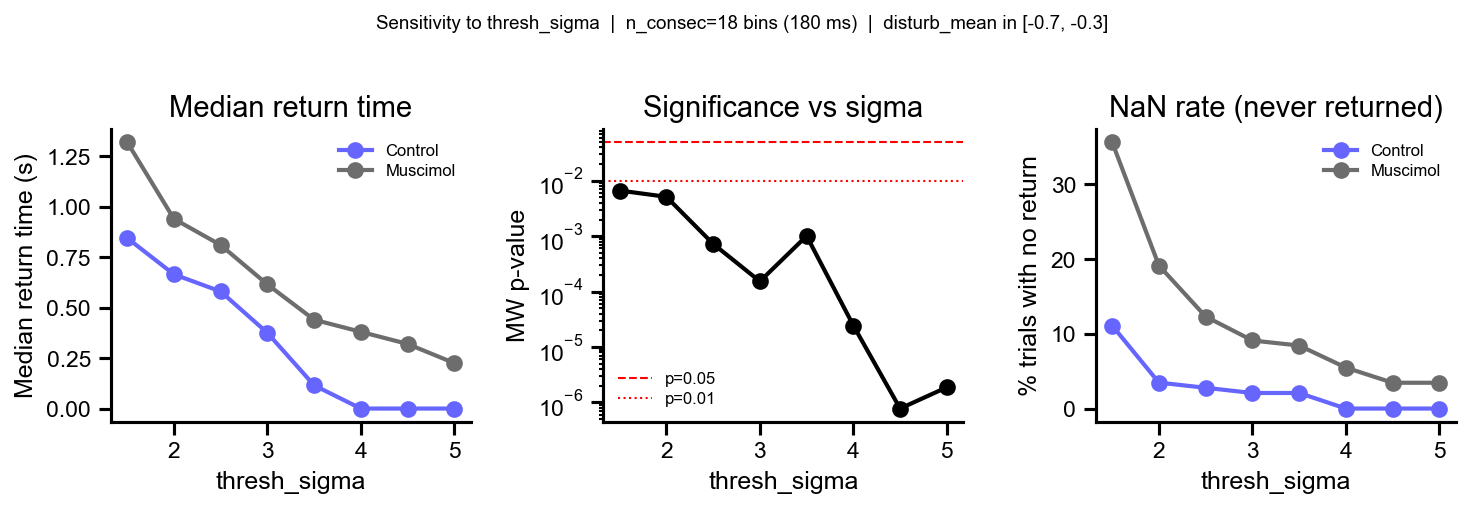

In [68]:
# -- Sensitivity sweep: thresh_sigma (n_consec fixed at 15) --
# For each sigma value: compute pooled control vs muscimol return times,
# record medians, % nans, and MW p-value.

import scipy.stats

N_CONSEC = 18
SIGMAS   = [1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]

# re-use sess_info and D_LO/D_HI from the cell above
results = []
for sigma in SIGMAS:
    rt_sweep = {}
    for animal, conds in sess_info.items():
        for cond, sess in conds.items():
            td = all_sess_no_drop.get(sess)
            if td is None:
                continue
            arr, _ = hip_return_times(td, D_LO, D_HI, ONSET_BIN, N_CONSEC, sigma)
            valid = arr[~np.isnan(arr)]
            nan_pct = np.isnan(arr).mean() * 100
            rt_sweep[(animal, cond)] = (valid, nan_pct)

    # pool across animals
    pool = {}
    nan_pool = {}
    for (animal, cond), (valid, nan_pct) in rt_sweep.items():
        pool.setdefault(cond, []).extend(valid)
        nan_pool.setdefault(cond, []).append(nan_pct)

    g1 = np.array(pool.get('normal-long', []))
    g2 = np.array(pool.get('muscimol', []))
    if len(g1) > 1 and len(g2) > 1:
        _, p_val = scipy.stats.mannwhitneyu(g1, g2, alternative='two-sided')
    else:
        p_val = np.nan
    results.append({
        'sigma':      sigma,
        'med_ctrl':   np.median(g1) if len(g1) > 0 else np.nan,
        'med_musc':   np.median(g2) if len(g2) > 0 else np.nan,
        'nan_ctrl':   np.mean(nan_pool.get('normal-long', [np.nan])),
        'nan_musc':   np.mean(nan_pool.get('muscimol',    [np.nan])),
        'p_val':      p_val,
        'n_ctrl':     len(g1),
        'n_musc':     len(g2),
    })
    print(f"sigma={sigma:.1f}  ctrl_med={results[-1]['med_ctrl']:.3f}s  "
          f"musc_med={results[-1]['med_musc']:.3f}s  "
          f"nan_ctrl={results[-1]['nan_ctrl']:.1f}%  "
          f"nan_musc={results[-1]['nan_musc']:.1f}%  "
          f"p={p_val:.3f}")

sigmas   = [r['sigma']    for r in results]
med_ctrl = [r['med_ctrl'] for r in results]
med_musc = [r['med_musc'] for r in results]
pvals    = [r['p_val']    for r in results]
nan_ctrl = [r['nan_ctrl'] for r in results]
nan_musc = [r['nan_musc'] for r in results]

with rc_context_talk():
    fig, axes = plt.subplots(1, 3, figsize=(10, 3.5))

    # Panel 1: median return time vs sigma
    ax = axes[0]
    ax.plot(sigmas, med_ctrl, 'o-', color=plt.cm.bwr(0.2), label='Control')
    ax.plot(sigmas, med_musc, 'o-', color='#6D6D6D',        label='Muscimol')
    ax.set_xlabel('thresh_sigma')
    ax.set_ylabel('Median return time (s)')
    ax.set_title('Median return time')
    ax.legend(fontsize=8)

    # Panel 2: MW p-value vs sigma (log scale)
    ax = axes[1]
    ax.plot(sigmas, pvals, 'ko-')
    ax.axhline(0.05, color='r', lw=1, ls='--', label='p=0.05')
    ax.axhline(0.01, color='r', lw=1, ls=':',  label='p=0.01')
    ax.set_yscale('log')
    ax.set_xlabel('thresh_sigma')
    ax.set_ylabel('MW p-value')
    ax.set_title('Significance vs sigma')
    ax.legend(fontsize=8)

    # Panel 3: % nan (trials that never returned) vs sigma
    ax = axes[2]
    ax.plot(sigmas, nan_ctrl, 'o-', color=plt.cm.bwr(0.2), label='Control')
    ax.plot(sigmas, nan_musc, 'o-', color='#6D6D6D',        label='Muscimol')
    ax.set_xlabel('thresh_sigma')
    ax.set_ylabel('% trials with no return')
    ax.set_title('NaN rate (never returned)')
    ax.legend(fontsize=8)

    plt.suptitle(f'Sensitivity to thresh_sigma  |  n_consec={N_CONSEC} bins ({N_CONSEC*10} ms)  |  '
                 f'disturb_mean in [{D_LO}, {D_HI}]', fontsize=9)
    plt.tight_layout()
    plt.show()
